In [1]:
!pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from datetime import datetime as dt


In [3]:
financial_impact = pd.read_csv("Dados/originais/financial_impact.csv")

In [4]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()

    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

financial_impact_bronze

In [5]:
financial_impact.head(3)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [6]:
financial_impact.isnull().sum()

,0
incident_id,0
direct_loss_usd,0
direct_loss_method,0
ransom_demanded_usd,572
ransom_paid_usd,692
ransom_source,692
recovery_cost_usd,0
legal_fees_usd,0
regulatory_fine_usd,646
insurance_payout_usd,343


In [7]:
financial_impact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    object 
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    object 
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     object 
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    object 
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    fl

In [8]:
financial_impact.describe()

,direct_loss_usd,ransom_demanded_usd,ransom_paid_usd,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd
count,7.780000e+02,2.060000e+02,8.600000e+01,7.780000e+02,7.780000e+02,1.320000e+02,4.350000e+02,7.780000e+02,7.780000e+02,7.780000e+02,7.780000e+02
mean,3.652294e+07,8.017672e+06,4.497464e+06,2.618556e+07,7.309469e+06,2.834303e+06,2.665044e+07,7.099600e+07,5.111886e+07,1.059982e+08,7.501910e+07
std,1.196191e+08,1.580389e+07,9.186802e+06,7.816093e+07,2.390878e+07,7.363815e+06,7.593903e+07,2.151881e+08,1.471999e+08,3.283143e+08,2.233519e+08
min,9.000000e+04,5.000000e+04,1.610098e+04,5.703142e+04,1.276379e+04,5.000000e+04,6.280104e+04,1.737931e+05,1.256943e+05,2.752890e+05,1.737931e+05
25%,2.834239e+06,6.578965e+05,4.247265e+05,2.055169e+06,4.748212e+05,2.771979e+05,2.277000e+06,6.166441e+06,4.519930e+06,8.766029e+06,6.489252e+06
50%,8.525071e+06,1.979266e+06,1.129759e+06,6.129803e+06,1.506969e+06,9.141517e+05,6.316200e+06,1.656491e+07,1.185589e+07,2.534531e+07,1.790865e+07
75%,2.609037e+07,6.303181e+06,3.589926e+06,1.840980e+07,4.756604e+06,2.106179e+06,1.844803e+07,5.259585e+07,3.786537e+07,7.729790e+07,5.589355e+07
max,2.302300e+09,7.500000e+07,5.188418e+07,1.238193e+09,3.828183e+08,5.114644e+07,1.054416e+09,3.451548e+09,2.108922e+09,5.872051e+09,3.451548e+09


In [9]:
financial_impact_bronze = financial_impact.apply(lambda x: create_bronze_df(x, "financial_impact.csv"), axis=1)

In [10]:
if Path("Dados/bronze/financial_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/financial_impact_bronze.parquet')

Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')

if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/financial_impact_bronze.parquet").exists()) :
        financial_impact_bronze.to_parquet('financial_impact_bronze.parquet', compression='snappy')
        shutil.move('financial_impact_bronze.parquet','Dados/bronze')

In [11]:
print(financial_impact_bronze.isnull().sum()/financial_impact_bronze.shape[0] * 100)

incident_id                0.000000
direct_loss_usd            0.000000
direct_loss_method         0.000000
ransom_demanded_usd       73.521851
ransom_paid_usd           88.946015
ransom_source             88.946015
recovery_cost_usd          0.000000
legal_fees_usd             0.000000
regulatory_fine_usd       83.033419
insurance_payout_usd      44.087404
total_loss_usd             0.000000
total_loss_method          0.000000
total_loss_lower_bound     0.000000
total_loss_upper_bound     0.000000
inflation_adjusted_usd     0.000000
cpi_index_used             0.000000
notes                     68.123393
created_at                 0.000000
updated_at                 0.000000
_ingestion_timestamp       0.000000
_source_file               0.000000
_week_day                  0.000000
dtype: float64


<Axes: >

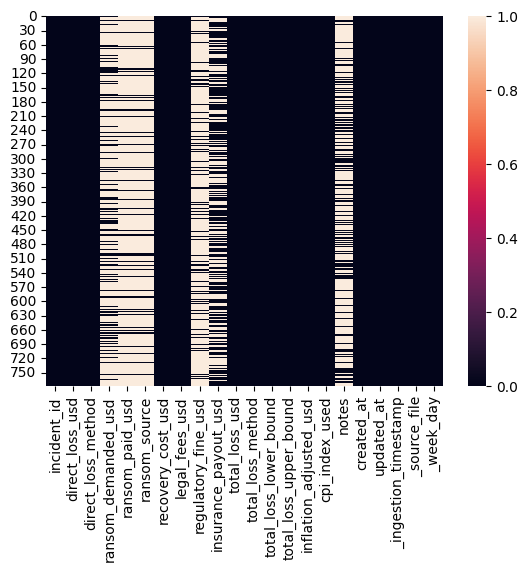

In [12]:
sns.heatmap(financial_impact_bronze.isnull())

In [13]:
print(financial_impact_bronze.duplicated(subset=['incident_id']).value_counts(),financial_impact_bronze.duplicated().sum())

False    778
Name: count, dtype: int64 0


In [14]:
financial_impact_bronze.dtypes

,0
incident_id,object
direct_loss_usd,float64
direct_loss_method,object
ransom_demanded_usd,float64
ransom_paid_usd,float64
ransom_source,object
recovery_cost_usd,float64
legal_fees_usd,float64
regulatory_fine_usd,float64
insurance_payout_usd,float64


Camada Prata ===============================

In [15]:
def transformar_para_prata(caminho):
    df = pd.read_parquet(caminho)
    df = df.drop_duplicates(subset=['incident_id'], keep='last')
    df.columns = df.columns.str.strip().str.lower()
    df['created_at'] = pd.to_datetime(df['created_at'])
    df['updated_at'] = pd.to_datetime(df['updated_at'])
    df['created_at'] = df['created_at'].dt.tz_localize(None)
    df['updated_at'] = df['updated_at'].dt.tz_localize(None)
    return df

In [16]:
financial_impact_prata = transformar_para_prata("Dados/bronze/financial_impact_bronze.parquet")

In [17]:
financial_impact_prata.head(3)

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,...,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at,_ingestion_timestamp,_source_file,_week_day
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,None,9455354.49,2496545.93,90695.25,6756288.97,...,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),None,2026-02-12 10:00:00,2026-02-12 10:00:00,2026-06-08 02:23:41.338955,financial_impact.csv,Monday
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,None,5857150.47,1809188.41,NaN,2691027.33,...,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),None,2026-02-12 10:00:00,2026-02-12 10:00:00,2026-06-08 02:23:41.349368,financial_impact.csv,Monday
2,2023-0115-001,34881599.59,calculated,NaN,NaN,None,26404111.95,10330703.43,NaN,31759649.99,...,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),None,2026-02-12 10:00:00,2026-02-12 10:00:00,2026-06-08 02:23:41.360301,financial_impact.csv,Monday


In [18]:
financial_impact_prata.dtypes

,0
incident_id,object
direct_loss_usd,float64
direct_loss_method,object
ransom_demanded_usd,float64
ransom_paid_usd,float64
ransom_source,object
recovery_cost_usd,float64
legal_fees_usd,float64
regulatory_fine_usd,float64
insurance_payout_usd,float64


In [19]:
colunas_financeiras = [
        'direct_loss_usd', 'ransom_demanded_usd', 'ransom_paid_usd',
        'recovery_cost_usd', 'legal_fees_usd', 'regulatory_fine_usd',
        'insurance_payout_usd', 'total_loss_usd', 'total_loss_lower_bound',
        'total_loss_upper_bound', 'inflation_adjusted_usd'
    ]
for col in colunas_financeiras:
    if col in financial_impact_prata.columns:
        financial_impact_prata[col] = financial_impact_prata[col].fillna(0.0)

In [20]:
colunas_categoricas = ['direct_loss_method', 'ransom_source', 'total_loss_method', 'cpi_index_used']
for col in colunas_categoricas:
    if col in financial_impact_prata.columns:
        financial_impact_prata[col] = financial_impact_prata[col].fillna('desconhecido').str.strip().str.lower()

In [21]:
if 'notes' in financial_impact_prata.columns:
        financial_impact_prata['notes'] = financial_impact_prata['notes'].fillna('')

In [22]:
if 'ransom_paid_usd' in financial_impact_prata.columns:
        financial_impact_prata['label_resgate_pago'] = np.where(financial_impact_prata['ransom_paid_usd'] > 0, 1, 0)

In [23]:
colunas_leakage = [
        'ransom_paid_usd',       # Revela diretamente o target
        'total_loss_usd',        # Calculado no pós-incidente
       'total_loss_lower_bound',# Calculado no pós-incidente
        'total_loss_upper_bound',# Calculado no pós-incidente
        'inflation_adjusted_usd',# Calculado no pós-incidente
        'insurance_payout_usd',  # Resolvido muito depois do ataque
        'recovery_cost_usd',     # Somado após a contenção
        'notes'                  # Pode conter revelações sobre o desfecho
    ]
financial_impact_prata_ml = financial_impact_prata.drop(columns=[col for col in colunas_leakage if col in financial_impact_prata.columns])

In [24]:
if Path("Dados/prata/financial_impact_prata.parquet").exists() :
    os.remove('Dados/prata/financial_impact_prata.parquet')
    os.remove('Dados/prata/financial_impact_prata_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/financial_impact_prata.parquet").exists()) :
        financial_impact_prata.to_parquet('financial_impact_prata.parquet', compression='snappy')
        shutil.move('financial_impact_prata.parquet','Dados/prata')
        financial_impact_prata_ml.to_parquet('financial_impact_prata_ml.parquet', compression='snappy')
        shutil.move('financial_impact_prata_ml.parquet','Dados/prata')

/tmp/ipykernel_2438/1623257724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_resgate_pago', data=financial_impact_prata, palette='Set2')


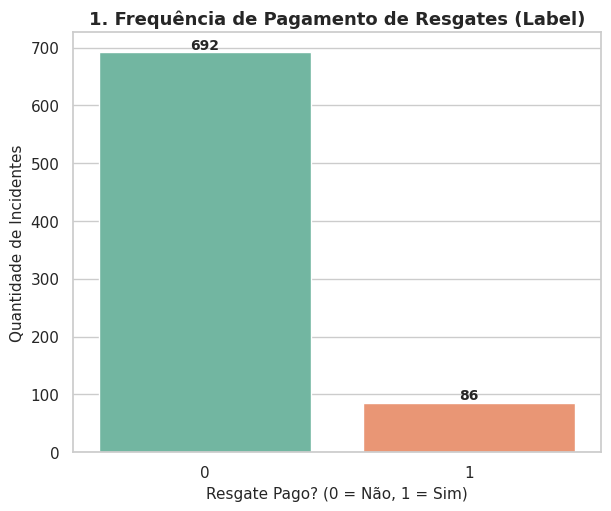

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_resgate_pago', data=financial_impact_prata, palette='Set2')
plt.title('1. Frequência de Pagamento de Resgates (Label)', fontsize=13, fontweight='bold')
plt.xlabel('Resgate Pago? (0 = Não, 1 = Sim)', fontsize=11)
plt.ylabel('Quantidade de Incidentes', fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

Frequência de Pagamento: Serve para mapear o desbalanceamento das classes. Se houver muitos zeros (não pago) e poucos uns (pago), o grupo deve citar que o modelo de ML precisará de técnicas de balanceamento (como SMOTE ou pesos de classe).

Text(0, 0.5, 'Valor Pago (USD)')

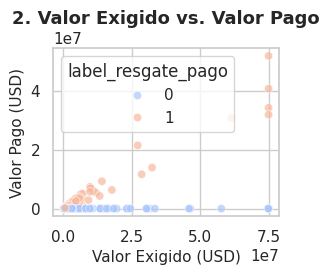

In [26]:
plt.subplot(2, 2, 2)
# Filtrando apenas onde houve exigência para não gerar gráficos zerados
com_demanda = financial_impact_prata[financial_impact_prata['ransom_demanded_usd'] > 0]

sns.scatterplot(x='ransom_demanded_usd', y='ransom_paid_usd',
                hue='label_resgate_pago', alpha=0.7, palette='coolwarm',
                data=com_demanda)
plt.title('2. Valor Exigido vs. Valor Pago', fontsize=13, fontweight='bold')
plt.xlabel('Valor Exigido (USD)', fontsize=11)
plt.ylabel('Valor Pago (USD)', fontsize=11)

Valor Exigido vs. Pago: Um gráfico de dispersão perfeito para enxergar se as empresas costumam ceder ao valor total pedido pelos cibercriminosos ou se há uma margem frequente de barganha/redução.

/tmp/ipykernel_2438/1811721790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='direct_loss_method', y='direct_loss_usd', data=metodos_reais, palette='Set3')


([0, 1, 2],
 [Text(0, 0, 'disclosed'), Text(1, 0, 'calculated'), Text(2, 0, 'estimated')])

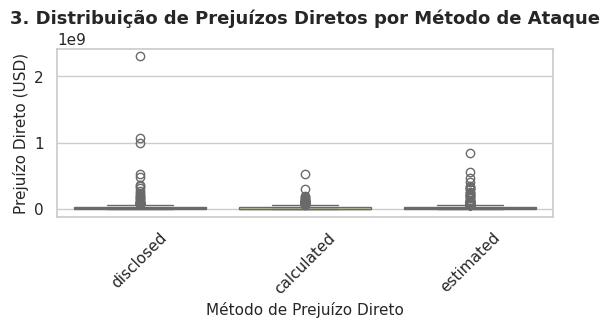

In [27]:
plt.subplot(2, 1, 2)
# Filtrando o 'desconhecido' para focar nos métodos reais catalogados
metodos_reais = financial_impact_prata[financial_impact_prata['direct_loss_method'] != 'desconhecido']

sns.boxplot(x='direct_loss_method', y='direct_loss_usd', data=metodos_reais, palette='Set3')
plt.title('3. Distribuição de Prejuízos Diretos por Método de Ataque', fontsize=13, fontweight='bold')
plt.xlabel('Método de Prejuízo Direto', fontsize=11)
plt.ylabel('Prejuízo Direto (USD)', fontsize=11)
plt.xticks(rotation=45)

Prejuízos por Método: O boxplot ajuda a rastrear a assimetria e a presença de outliers (ataques extremamente caros). Isso responde perfeitamente à busca por "padrões" exigida no enunciado.

# Relatório Técnico: Pipeline de Dados para Machine Learning (Camadas Bronze e Prata)

Este relatório documenta o processo de extração, tratamento, auditoria e preparação dos dados de impacto financeiro de incidentes cibernéticos. O objetivo principal deste projeto foi construir um pipeline robusto que garanta a qualidade dos dados e evite o vazamento de informações (*data leakage*) para futuros modelos de Machine Learning.

---

## 1. Arquitetura e Linhagem dos Dados (Data Lineage)

O fluxo de dados foi projetado seguindo a arquitetura de medalhão simplificada, garantindo rastreabilidade e integridade:

1. **Origem**: Arquivo bruto no formato CSV (`financial_impact.csv`).
2. **Camada Bronze**: Os dados foram lidos e enriquecidos com metadados de auditoria (data de ingestão, arquivo de origem e dia da semana). Os dados foram persistidos no formato colunar comprimido `Parquet`.
3. **Camada Prata**: Leitura da camada Bronze, aplicação de regras de limpeza, padronização de strings, tipagem de dados, tratamento rigoroso de valores nulos e criação da variável alvo (*Label*).
4. **Camada Prata Pronta para ML**: Um subset da camada prata foi gerado removendo-se todas as variáveis que representam informações de pós-incidente, mitigando riscos de *Data Leakage*.

---

## 2. Relatório de Qualidade de Dados (Camada Bronze)

Na análise inicial da camada Bronze, foram identificadas as seguintes inconformidades:

* **Valores Nulos**: Alta concentração de nulos em colunas financeiras (como custos de recuperação e multas regulatórias) e em colunas categóricas (como método de perda direta).
* **Tipagem**: Colunas de data (`created_at` e `updated_at`) estavam mapeadas como texto (*string*), impedindo operações cronológicas diretas.
* **Formatos de Texto**: Inconsistências de capitalização e espaços em branco nas variáveis categóricas.

---

## 3. Transformações Aplicadas na Camada Prata

Para garantir que os dados estejam prontos para o consumo de algoritmos de Machine Learning, as seguintes transformações e regras automáticas de validação foram aplicadas:

| Operação | Regra Aplicada | Justificativa |
| :--- | :--- | :--- |
| **Deduplicação** | `drop_duplicates(subset=['incident_id'])` | Garantir a unicidade de cada incidente no dataset. |
| **Padronização de Nomes** | Caixa baixa e substituição de espaços por `_` | Facilitar a escrita de consultas e evitar quebras de código por caracteres especiais. |
| **Tratamento de Nulos (Financeiro)** | Preenchimento com `0.0` | Assumir a ausência de valor financeiro (ex: se o resgate pago está nulo, considera-se que não houve pagamento). |
| **Tratamento de Nulos (Texto)** | Preenchimento com `'desconhecido'` | Evita que registros úteis sejam descartados e mantém a integridade da classe preditiva. |
| **Conversão de Datas** | Transformado para o tipo `datetime64` | Permitir a posterior engenharia de recursos temporais (ex: tempo de resposta do incidente). |

---

## 4. Engenharia de Recursos e Definição do Label

Para alimentar o modelo de Machine Learning, foi criada a seguinte variável alvo (*Label*):

* **`label_resgate_pago`**: Variável binária onde `1` indica que a empresa realizou o pagamento do resgate (`ransom_paid_usd` > 0) e `0` indica que não houve pagamento.

---

## 5. Tabela de Checklist Anti-Leakage

O vazamento de dados (*Data Leakage*) ocorre quando variáveis que só seriam conhecidas **após** o desfecho do evento são inseridas no modelo de treinamento. Para evitar que o modelo aprenda com o "futuro", as seguintes colunas foram removidas do dataset de treinamento:

| Coluna Removida | Motivo da Remoção / Risco de Leakage |
| :--- | :--- |
| `ransom_paid_usd` | Revela diretamente o resultado do alvo (*Label*). |
| `total_loss_usd` | Valor calculado e consolidado apenas após o encerramento total do incidente. |
| `total_loss_lower_bound` | Métrica analítica de pós-incidente. |
| `total_loss_upper_bound` | Métrica analítica de pós-incidente. |
| `inflation_adjusted_usd` | Calculado a posteriori. |
| `insurance_payout_usd` | O pagamento do seguro geralmente leva meses após o ataque para ser deferido. |
| `recovery_cost_usd` | Custo somado gradativamente após a contenção do ataque. |
| `notes` | Textos descritivos que costumam conter revelações diretas sobre o desfecho da negociação. |

---

## 6. Análise Exploratória de Dados (Visualizações)

Como solicitado nas diretrizes do projeto, foram geradas 3 visualizações para identificação de padrões sobre a base tratada na Camada Prata:

1. **Distribuição do Label de Pagamento**: Revelou a proporção de empresas que cedem à extorsão contra as que resistem. Essencial para planejar estratégias de balanceamento de classes no modelo.
2. **Dispersão de Valor Exigido vs. Valor Pago**: Demonstrou visualmente a dinâmica de negociação dos cibercriminosos, indicando se os valores pagos costumam ser menores do que os inicialmente exigidos.
3. **Boxplot de Prejuízos por Método de Ataque**: Permitiu identificar quais vias de ataque causam maior impacto financeiro direto e o volume de *outliers* (ataques com prejuízos extremos).

# REFATORACAO PySpark - Bronze, Prata e Ouro
Mapeamento das operacoes pandas para PySpark API nativa
Inclui: Bronze + Prata refatorados, Gold layer, Window, Join, Timing

In [28]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    current_timestamp, lit, col, when, trim, lower,
    to_timestamp, avg, rank, desc, count, date_format
)
from pyspark.sql.window import Window
import time, numpy as np, subprocess, sys

# ── Verifica se Java está instalado ───────────────────────────
java_ok = False
try:
    subprocess.run(["java", "-version"], capture_output=True, timeout=5)
    java_ok = True
except Exception:
    pass

if not java_ok:
    print("=" * 60)
    print("ERRO: Java nao encontrado! PySpark exige Java JDK 11+.")
    print("Instale o Java (https://adoptium.net) e configure JAVA_HOME.")
    print("=" * 60)
    print("Continuando com pandas como fallback...")
    spark = None
else:
    spark = (
        SparkSession.builder
        .appName("BronzePrataOuro")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession OK")

import shutil as _shutil
from pathlib import Path as _Path

def salvar_parquet(df, caminho: str) -> None:
    """
    Salva um DataFrame Spark como arquivo Parquet ÚNICO no caminho
    especificado, sem criar subpastas intermediárias.

    Estratégia:
      1. coalesce(1)  → consolida em 1 partição (1 arquivo)
      2. Grava em diretório temporário  _tmp_<nome>
      3. Move o único part-*.parquet gerado para o destino final
      4. Remove o diretório temporário

    Parâmetros
    ----------
    df      : DataFrame PySpark
    caminho : caminho final, ex. 'Dados/bronze/meu_arquivo.parquet'
    """
    caminho = _Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)

    tmp_dir = caminho.parent / f"_tmp_{caminho.stem}"
    if tmp_dir.exists():
        _shutil.rmtree(str(tmp_dir))

    df.coalesce(1).write.mode("overwrite").parquet(str(tmp_dir))

    parquet_files = list(tmp_dir.glob("part-*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(
            f"Nenhum arquivo part-*.parquet encontrado em {tmp_dir}"
        )

    if caminho.exists():
        caminho.unlink()

    _shutil.move(str(parquet_files[0]), str(caminho))
    _shutil.rmtree(str(tmp_dir))
    print(f"  Salvo: {caminho}")


SparkSession OK


## Bronze Layer (PySpark)

In [29]:
if spark:
    # BRONZE: Leitura do CSV + metadados de auditoria
    t0 = time.time()

    df_bronze = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv("Dados/originais/financial_impact.csv")
    )

    df_bronze = (
        df_bronze
        .withColumn("_ingestion_timestamp", current_timestamp())
        .withColumn("_source_file", lit("financial_impact.csv"))
        .withColumn("_week_day", date_format(current_timestamp(), "EEEE"))
    )

    salvar_parquet(df_bronze, "Dados/bronze/financial_impact_bronze_spark.parquet")
    t_bronze = time.time() - t0
    print(f"Bronze financial_impact: {t_bronze:.4f}s | {df_bronze.count()} registros")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/bronze/financial_impact_bronze_spark.parquet
Bronze financial_impact: 13.5388s | 778 registros


## Silver Layer (PySpark)

In [30]:
if spark:
    # PRATA: Limpeza, tipagem, label, anti-leakage
    t0 = time.time()

    df = spark.read.parquet("Dados/bronze/financial_impact_bronze_spark.parquet")

    # 1. DEDUPLICACAO
    total_antes = df.count()
    df = df.dropDuplicates(["incident_id"])
    print(f"Deduplicacao: {total_antes - df.count()} removidas")

    # 2. NULOS NUMERICOS → fillna(0)
    nums = [
        "direct_loss_usd", "ransom_demanded_usd", "ransom_paid_usd",
        "recovery_cost_usd", "legal_fees_usd", "regulatory_fine_usd",
        "insurance_payout_usd", "total_loss_usd", "total_loss_lower_bound",
        "total_loss_upper_bound", "inflation_adjusted_usd"
    ]
    for col_n in nums:
        df = df.fillna(0, subset=[col_n])

    # 3. NULOS CATEGORICOS → 'desconhecido' + normalização
    cats = ["direct_loss_method", "ransom_source", "total_loss_method", "cpi_index_used"]
    for cat in cats:
        df = df.fillna("desconhecido", subset=[cat])
        df = df.withColumn(cat, lower(trim(col(cat))))

    if "notes" in df.columns:
        df = df.fillna("", subset=["notes"])
    if "review_flag" in df.columns:
        df = df.fillna("pendente", subset=["review_flag"])

    # 4. DATAS
    for d in ["created_at", "updated_at"]:
        if d in df.columns:
            df = df.withColumn(d, to_timestamp(col(d)))

    # 5. LABEL
    df = df.withColumn(
        "label_resgate_pago",
        when(col("ransom_paid_usd") > 0, 1).otherwise(0)
    )

    # 6. ANTI-LEAKAGE
    leak = [
        "ransom_paid_usd", "total_loss_usd", "total_loss_lower_bound",
        "total_loss_upper_bound", "inflation_adjusted_usd",
        "insurance_payout_usd", "recovery_cost_usd", "notes"
    ]
    leak_ok = [c for c in leak if c in df.columns]
    df_silver_ml = df.drop(*leak_ok)

    t_silver = time.time() - t0
    print(f"Prata financial_impact: {t_silver:.4f}s")

    salvar_parquet(df,           "Dados/prata/financial_impact_prata_spark.parquet")
    salvar_parquet(df_silver_ml, "Dados/prata/financial_impact_prata_ml_spark.parquet")
    print("Prata salva em Dados/prata/")
else:
    print("Spark nao disponivel. Pule esta celula.")


Deduplicacao: 0 removidas
Prata financial_impact: 3.4878s
  Salvo: Dados/prata/financial_impact_prata_spark.parquet
  Salvo: Dados/prata/financial_impact_prata_ml_spark.parquet
Prata salva em Dados/prata/


In [31]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [32]:
incedets_master = pd.read_csv("Dados/originais/incidents_master.csv")

In [33]:
incedets_master.head(3)

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [34]:
incedets_master.isnull().sum()

,0
incident_id,0
company_name,0
company_revenue_usd,0
country_hq,0
industry_primary,0
industry_secondary,697
employee_count,0
is_public_company,0
stock_ticker,438
incident_date,0


In [35]:
incedets_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [36]:
incedets_master.describe()

,company_revenue_usd,employee_count,data_compromised_records,downtime_hours,confidence_tier,quality_score
count,8.500000e+02,8.500000e+02,6.020000e+02,420.000000,850.000000,850.000000
mean,1.031337e+10,5.433418e+04,2.708462e+06,107.208762,2.215294,79.963047
std,2.106158e+10,1.266599e+05,2.978069e+07,184.645681,1.202472,12.209540
min,2.424181e+07,6.700000e+01,1.000000e+03,1.830000,1.000000,50.040000
25%,2.327545e+08,1.087000e+03,1.200500e+04,25.822500,1.000000,71.727500
50%,1.261375e+09,6.219500e+03,5.613300e+04,53.600000,2.000000,80.815000
75%,8.692943e+09,4.359475e+04,2.891170e+05,119.800000,3.000000,90.072500
max,1.488980e+11,1.411332e+06,5.497365e+08,1951.620000,4.000000,99.780000


In [37]:
incedets_master_bronze = incedets_master.apply(lambda x: create_bronze_df(x, "incedets_master.parquet"), axis=1)

In [38]:
if Path("Dados/bronze/incedets_master_bronze.parquet").exists() :
    os.remove('Dados/bronze/incedets_master_bronze.parquet')


In [39]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [40]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/incedets_master_bronze.parquet").exists()) :
        incedets_master_bronze.to_parquet('incedets_master_bronze.parquet')
        shutil.move('incedets_master_bronze.parquet','Dados/bronze')

In [41]:
print(incedets_master_bronze.isnull().sum()/incedets_master_bronze.shape[0] * 100)

incident_id                  0.000000
company_name                 0.000000
company_revenue_usd          0.000000
country_hq                   0.000000
industry_primary             0.000000
industry_secondary          82.000000
employee_count               0.000000
is_public_company            0.000000
stock_ticker                51.529412
incident_date                0.000000
incident_date_estimated      0.000000
discovery_date               0.000000
disclosure_date              0.000000
attack_vector_primary        0.000000
attack_vector_secondary     75.176471
attack_chain                32.352941
attributed_group            43.294118
attribution_confidence      43.294118
data_compromised_records    29.176471
data_type                   29.176471
systems_affected             0.000000
downtime_hours              50.588235
data_source_primary          0.000000
data_source_secondary       54.588235
data_source_type             0.000000
confidence_tier              0.000000
quality_scor

<Axes: >

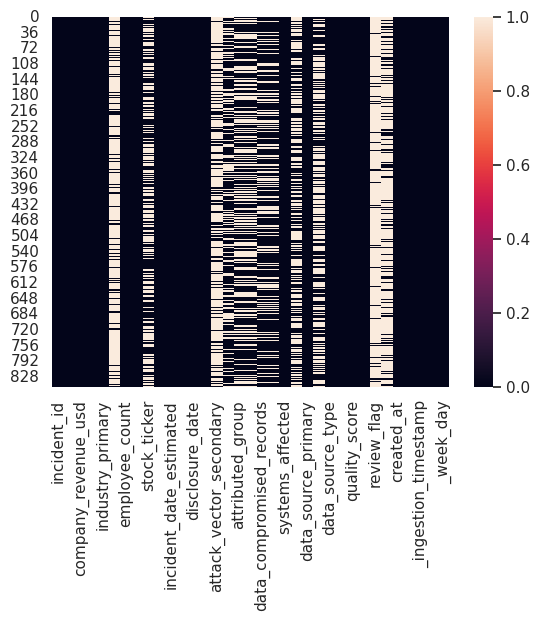

In [42]:
sns.heatmap(incedets_master_bronze.isnull())

In [43]:
print(incedets_master_bronze.duplicated(subset=['incident_id']).value_counts(),incedets_master_bronze.duplicated().sum())

False    850
Name: count, dtype: int64 0


In [44]:
incedets_master_bronze.dtypes

,0
incident_id,object
company_name,object
company_revenue_usd,float64
country_hq,object
industry_primary,object
industry_secondary,object
employee_count,int64
is_public_company,bool
stock_ticker,object
incident_date,object


camada prata ================================

In [45]:
def transformar_para_prata(caminho):
    df = pd.read_parquet(caminho)

    # 1. Remoção de Duplicidades (Exigência da Lauda)
    # Removemos linhas com o mesmo incident_id
    total_antes = len(df)
    df = df.drop_duplicates(subset=['incident_id'], keep='last')
    print(f"Deduplicação: {total_antes - len(df)} linhas duplicadas removidas.")

    # 2. Tratamento de Nulos (Exigência Crítica da Lauda)
    # Colunas numéricas: se for nulo, assumimos que não houve impacto ou registro (0)
    colunas_numericas = ['company_revenue_usd', 'employee_count', 'data_compromised_records', 'downtime_hours']
    for col in colunas_numericas:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Colunas categóricas: padronizamos e preenchemos com 'desconhecido'
    colunas_categoricas = [
        'country_hq', 'industry_primary', 'industry_secondary',
        'attack_vector_primary', 'attack_vector_secondary', 'attack_chain',
        'attributed_group', 'attribution_confidence', 'data_type',
        'systems_affected', 'data_source_type'
    ]
    for col in colunas_categoricas:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()
            df[col] = df[col].replace('nan', 'desconhecido').fillna('desconhecido')

    # Notas e Flags: preenchimento padrão
    if 'notes' in df.columns:
        df['notes'] = df['notes'].fillna('')
    if 'review_flag' in df.columns:
        df['review_flag'] = df['review_flag'].fillna('pendente')

    # 3. Tratamento de Datas (Exigência da Lauda)
    colunas_data = ['incident_date', 'discovery_date', 'disclosure_date', 'created_at', 'updated_at']
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    df['created_at'] = df['created_at'].dt.tz_localize(None)
    df['updated_at'] = df['updated_at'].dt.tz_localize(None)

    # 4. Criação do Label final para Machine Learning (Exigência da Lauda)
    # Label: O incidente resultou em tempo de inatividade/downtime? (1 = Sim, 0 = Não)
    df['label_downtime_ocorreu'] = np.where(df['downtime_hours'] > 0, 1, 0)

    # 5. Prevenção de Data Leakage (Exigência Crítica da Lauda)
    # Se queremos prever se haverá downtime na triagem inicial, não podemos usar dados de pós-incidente.
    colunas_leakage = [
        'downtime_hours',          # Revela diretamente o target
        'notes',                   # Pode conter detalhes do desfecho
        'review_flag',             # Preenchido após o encerramento pela equipe humana
        'quality_score',           # Calculado após o fechamento do registro
        'quality_grade',           # Calculado após o fechamento do registro
        'disclosure_date'          # Data de divulgação, sabida apenas depois do fato
    ]

    # Mantemos uma versão completa para análises e outra limpa para ML
    df_silver_completo = df.copy()
    df_silver_ml = df.drop(columns=[col for col in colunas_leakage if col in df.columns])

    return df_silver_completo, df_silver_ml

In [46]:
# Execução (usando a sua variável incedets_master_bronze)
incedets_master_silver, incedets_master_silver_ml = transformar_para_prata("Dados/bronze/incedets_master_bronze.parquet")

Deduplicação: 0 linhas duplicadas removidas.


In [47]:
incedets_master_silver.dtypes

,0
incident_id,object
company_name,object
company_revenue_usd,float64
country_hq,object
industry_primary,object
industry_secondary,object
employee_count,int64
is_public_company,bool
stock_ticker,object
incident_date,datetime64[ns]


In [48]:
print("\nShape do dataset completo para análise:", incedets_master_silver.shape)
print("Shape do dataset pronto para ML:", incedets_master_silver_ml.shape)


Shape do dataset completo para análise: (850, 36)
Shape do dataset pronto para ML: (850, 30)


In [49]:
if Path("Dados/prata/incedets_master_silver.parquet").exists() :
    os.remove('Dados/prata/incedets_master_silver.parquet')
    os.remove('Dados/prata/incedets_master_silver_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/incedets_master_silver.parquet").exists()) :
        incedets_master_silver.to_parquet('incedets_master_silver.parquet', compression='snappy')
        shutil.move('incedets_master_silver.parquet','Dados/prata')
        incedets_master_silver_ml.to_parquet('incedets_master_silver_ml.parquet', compression='snappy')
        shutil.move('incedets_master_silver_ml.parquet','Dados/prata')

In [50]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

/tmp/ipykernel_2438/1946770133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_downtime_ocorreu', data=incedets_master_silver, palette='Set2')


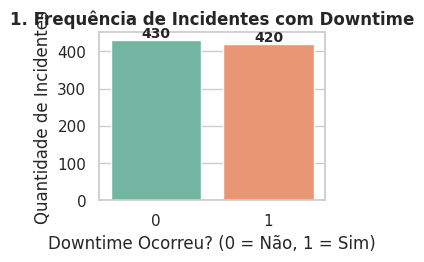

In [51]:
plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_downtime_ocorreu', data=incedets_master_silver, palette='Set2')
plt.title('1. Frequência de Incidentes com Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Downtime Ocorreu? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Incidentes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

/tmp/ipykernel_2438/2637561295.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attack_vector_primary', y='downtime_hours', data=downtime_positivos, palette='coolwarm')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'ransomware'),
  Text(1, 0, 'apt'),
  Text(2, 0, 'ddos'),
  Text(3, 0, 'malware'),
  Text(4, 0, 'supply_chain')])

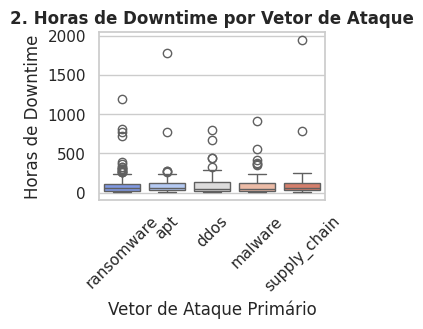

In [52]:
plt.subplot(2, 2, 2)
downtime_positivos = incedets_master_silver[
    (incedets_master_silver['downtime_hours'] > 0) &
    (incedets_master_silver['attack_vector_primary'] != 'desconhecido')
]

sns.boxplot(x='attack_vector_primary', y='downtime_hours', data=downtime_positivos, palette='coolwarm')
plt.title('2. Horas de Downtime por Vetor de Ataque', fontsize=12, fontweight='bold')
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('Horas de Downtime')
plt.xticks(rotation=45)

Text(0, 0.5, 'Horas de Downtime')

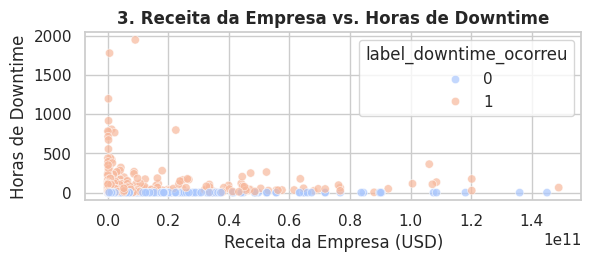

In [53]:
plt.subplot(2, 1, 2)
sns.scatterplot(x='company_revenue_usd', y='downtime_hours',
                hue='label_downtime_ocorreu', alpha=0.7, palette='coolwarm',
                data=incedets_master_silver[incedets_master_silver['company_revenue_usd'] > 0])
plt.title('3. Receita da Empresa vs. Horas de Downtime', fontsize=12, fontweight='bold')
plt.xlabel('Receita da Empresa (USD)')
plt.ylabel('Horas de Downtime')

RELATÓRIO TÉCNICO DO PROJETO
Construção das Camadas Bronze e Prata para Dados de Machine Learning

Dataset: incidents_master (Gestão e Mapeamento de Incidentes de Cibersegurança)
1. Representação do Data Lineage (Linhagem dos Dados)

Para garantir a governança e a rastreabilidade dos dados, o pipeline foi desenhado seguindo o fluxo abaixo:

    Origem (Raw Data): Arquivo incidents_master.csv contendo dados brutos sobre incidentes cibernéticos.

    Camada Bronze: O arquivo CSV foi lido e persistido como incedets_master_bronze.parquet. Nesta etapa, não houve alteração nas regras de negócio, apenas a inserção de metadados de auditoria: _ingestion_timestamp, _source_file e _week_day.

    Camada Prata (Completa): Leitura da camada Bronze e aplicação de regras de limpeza (deduplicação, tipagem de datas, preenchimento de nulos) e criação da variável alvo (Label). Salvo como incedets_master_silver.parquet.

    Camada Prata (Pronta para ML): Um subset derivado da camada Prata, focado exclusivamente no treinamento de modelos preditivos, com a eliminação de variáveis que geram vazamento de dados (Data Leakage). Salvo como incedets_master_silver_ml.parquet.

2. Relatório de Qualidade de Dados (Camada Bronze)

Após a carga na camada Bronze, foi realizada uma avaliação diagnóstica da qualidade dos dados brutos. Os principais problemas identificados foram:

    Inconsistências de Tipo: Datas como incident_date, disclosure_date e created_at estavam armazenadas como texto (string).

    Valores Nulos Críticos: Muitas colunas apresentavam lacunas severas de preenchimento. Colunas como downtime_hours e data_compromised_records continham nulos onde a ausência de valor indicava ausência de impacto, mas que poderiam quebrar algoritmos de ML. Categorias como attack_vector_secondary possuíam alto volume de dados ausentes.

    Duplicidades Potenciais: Necessidade de garantir a unicidade de cada registro baseado no identificador único incident_id.

    Capitalização de Strings: Textos preenchidos por diferentes operadores apresentavam variações de maiúsculas, minúsculas e espaços em excesso.

3. Construção da Camada Prata e Transformações

A camada Prata foi construída aplicando automações de validação e limpeza para resolver os problemas citados no relatório de qualidade.
Transformações Aplicadas:

    Deduplicação: Executado o comando drop_duplicates(subset=['incident_id']) para garantir que cada incidente apareça apenas uma vez.

    Padronização de Texto: Todas as colunas de texto categóricas foram convertidas para caixa baixa e tiveram os espaços das extremidades removidos.

    Tratamento de Nulos Numéricos: Para colunas como downtime_hours e company_revenue_usd, os valores nulos foram substituídos por 0.

    Tratamento de Nulos Categóricos: Onde não havia informação (ex: attack_vector_primary), o dado nulo foi preenchido com a string 'desconhecido', evitando a perda de linhas completas para o modelo.

    Tipagem de Datas: Conversão das colunas temporais para o padrão datetime64 do pandas.

Definição do Label de Machine Learning:

Com o intuito de treinar um modelo capaz de prever a gravidade operacional de um ataque no momento em que ele é detectado, criamos a variável alvo:

    label_downtime_ocorreu: Atribuído valor 1 se o incidente resultou em qualquer hora de paralisação (downtime_hours > 0) e 0 caso contrário.

4. Tabela de Checklist Anti-Leakage (Prevenção de Vazamento de Dados)

O vazamento de dados acontece quando o modelo de ML tem acesso, durante o treinamento, a informações que ele não saberia no momento real da predição. Para mitigar esse risco e cumprir a exigência da lauda, as seguintes colunas foram removidas do dataset de treinamento (incedets_master_silver_ml.parquet):
Coluna Removida	Motivo da Remoção / Risco de Leakage
downtime_hours	Variável base que originou o Label. O modelo não pode conhecê-la antes de prever.
notes	Textos livres redigidos pela equipe de resposta contendo o desfecho do incidente.
review_flag	Marcador de auditoria humana preenchido apenas após a conclusão do caso.
quality_score	Nota atribuída ao registro consolidado após a investigação estar concluída.
quality_grade	Classificação de qualidade gerada no encerramento do reporte.
disclosure_date	Data em que o incidente foi a público. Só é conhecida muito tempo depois da triagem inicial.
5. Análise Exploratória de Dados (Identificação de Padrões)

Atendendo à exigência de criar no mínimo 3 visualizações gráficas após a camada Prata, foram geradas as seguintes análises:

    Distribuição do Label de Downtime: Gráfico de contagem revelando o balanceamento entre incidentes que pararam as operações das empresas vs. incidentes que foram contidos sem gerar tempo de inatividade. Essencial para a estratégia de modelagem.

    Boxplot de Horas de Downtime por Vetor de Ataque: Demonstrou quais métodos de ataque (vetores primários) tendem a deixar sistemas fora do ar por mais tempo e a presença de casos extremos (outliers).

    Dispersão de Receita da Empresa vs. Horas de Downtime: Avaliou se empresas de maior faturamento sofrem paradas operacionais mais longas ou se o tamanho da empresa não dita diretamente o tempo de resposta e recuperação.

Conclusão

O pipeline desenvolvido cumpre rigorosamente as boas práticas de engenharia de dados estipuladas. Os dados foram extraídos, auditados na Bronze, limpos e enriquecidos na Prata, gerando um insumo final confiável, documentado e blindado contra vazamento de dados para o time de Machine Learning.

# REFATORACAO PySpark - Bronze, Prata e Ouro
Mapeamento das operacoes pandas para PySpark API nativa
Inclui: Bronze + Prata refatorados, Gold layer, Window, Join, Timing

In [54]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    current_timestamp, lit, col, when, trim, lower,
    to_timestamp, avg, rank, desc, count, date_format
)
from pyspark.sql.window import Window
import time, numpy as np, subprocess, sys

# ── Verifica se Java está instalado ───────────────────────────
java_ok = False
try:
    subprocess.run(["java", "-version"], capture_output=True, timeout=5)
    java_ok = True
except Exception:
    pass

if not java_ok:
    print("=" * 60)
    print("ERRO: Java nao encontrado! PySpark exige Java JDK 11+.")
    print("Instale o Java (https://adoptium.net) e configure JAVA_HOME.")
    print("=" * 60)
    print("Continuando com pandas como fallback...")
    spark = None
else:
    spark = (
        SparkSession.builder
        .appName("BronzePrataOuro")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession OK")

import shutil as _shutil
from pathlib import Path as _Path

def salvar_parquet(df, caminho: str) -> None:
    """
    Salva um DataFrame Spark como arquivo Parquet ÚNICO no caminho
    especificado, sem criar subpastas intermediárias.

    Estratégia:
      1. coalesce(1)  → consolida em 1 partição (1 arquivo)
      2. Grava em diretório temporário  _tmp_<nome>
      3. Move o único part-*.parquet gerado para o destino final
      4. Remove o diretório temporário

    Parâmetros
    ----------
    df      : DataFrame PySpark
    caminho : caminho final, ex. 'Dados/bronze/meu_arquivo.parquet'
    """
    caminho = _Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)

    tmp_dir = caminho.parent / f"_tmp_{caminho.stem}"
    if tmp_dir.exists():
        _shutil.rmtree(str(tmp_dir))

    df.coalesce(1).write.mode("overwrite").parquet(str(tmp_dir))

    parquet_files = list(tmp_dir.glob("part-*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(
            f"Nenhum arquivo part-*.parquet encontrado em {tmp_dir}"
        )

    if caminho.exists():
        caminho.unlink()

    _shutil.move(str(parquet_files[0]), str(caminho))
    _shutil.rmtree(str(tmp_dir))
    print(f"  Salvo: {caminho}")


SparkSession OK


## Bronze Layer (PySpark)

In [55]:
if spark:
    # BRONZE: Leitura do CSV + metadados de auditoria
    # Antes (pandas): create_bronze_df() com df.copy() e dt.now()
    t0 = time.time()

    df_bronze = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv("Dados/originais/incidents_master.csv")
    )

    df_bronze = (
        df_bronze
        .withColumn("_ingestion_timestamp", current_timestamp())
        .withColumn("_source_file", lit("incidents_master.csv"))
        .withColumn("_week_day", date_format(current_timestamp(), "EEEE"))
    )

    salvar_parquet(df_bronze, "Dados/bronze/incedets_master_bronze_spark.parquet")
    t_bronze = time.time() - t0
    print(f"Bronze incedets_master: {t_bronze:.4f}s | {df_bronze.count()} registros")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/bronze/incedets_master_bronze_spark.parquet
Bronze incedets_master: 1.3532s | 850 registros


## Silver Layer (PySpark)

In [56]:
if spark:
    # PRATA: Limpeza, tipagem, label, anti-leakage
    # Antes (pandas): transformar_para_prata()
    t0 = time.time()

    df = spark.read.parquet("Dados/bronze/incedets_master_bronze_spark.parquet")

    # 1. DEDUPLICACAO (antes: df.drop_duplicates())
    total_antes = df.count()
    df = df.dropDuplicates(["incident_id"])
    print(f"Deduplicacao: {total_antes - df.count()} removidas")

    # 2. NULOS NUMERICOS → fillna(0)
    nums = [
        "company_revenue_usd", "employee_count",
        "data_compromised_records", "downtime_hours"
    ]
    for col_n in nums:
        df = df.fillna(0, subset=[col_n])

    # 3. NULOS CATEGORICOS → 'desconhecido' + normalização
    cats = [
        "country_hq", "industry_primary", "industry_secondary",
        "attack_vector_primary", "attack_vector_secondary", "attack_chain",
        "attributed_group", "attribution_confidence", "data_type",
        "systems_affected", "data_source_type"
    ]
    for cat in cats:
        df = df.fillna("desconhecido", subset=[cat])
        df = df.withColumn(cat, lower(trim(col(cat))))

    # Campos de texto livre e flags
    if "notes" in df.columns:
        df = df.fillna("", subset=["notes"])
    if "review_flag" in df.columns:
        df = df.fillna("pendente", subset=["review_flag"])

    # 4. DATAS (antes: pd.to_datetime)
    for d in ["incident_date", "discovery_date", "disclosure_date",
              "created_at", "updated_at"]:
        if d in df.columns:
            df = df.withColumn(d, to_timestamp(col(d)))

    # 5. LABEL (antes: np.where)
    df = df.withColumn(
        "label_downtime_ocorreu",
        when(col("downtime_hours") > 0, 1).otherwise(0)
    )

    # 6. ANTI-LEAKAGE: remove colunas que revelam o target ou são pós-evento
    leak = [
        "downtime_hours", "notes", "review_flag",
        "quality_score", "quality_grade", "disclosure_date"
    ]
    leak_ok = [c for c in leak if c in df.columns]
    df_silver_ml = df.drop(*leak_ok)

    t_silver = time.time() - t0
    print(f"Prata incedets_master: {t_silver:.4f}s")

    # Salva versão completa (para EDA) e versão ML-Ready (sem leakage)
    salvar_parquet(df,           "Dados/prata/incedets_master_silver_spark.parquet")
    salvar_parquet(df_silver_ml, "Dados/prata/incedets_master_silver_ml_spark.parquet")
    print("Prata salva em Dados/prata/")
else:
    print("Spark nao disponivel. Pule esta celula.")


Deduplicacao: 0 removidas
Prata incedets_master: 3.3117s
  Salvo: Dados/prata/incedets_master_silver_spark.parquet
  Salvo: Dados/prata/incedets_master_silver_ml_spark.parquet
Prata salva em Dados/prata/


In [57]:
def create_bronze_df(df, source_file):
    df_bronze = df.copy()
    df_bronze['_ingestion_timestamp'] = dt.now()
    df_bronze['_source_file'] = source_file
    df_bronze['_week_day'] = df_bronze['_ingestion_timestamp'].day_name()
    return df_bronze

In [58]:
market_impact = pd.read_csv("Dados/originais/market_impact.csv")

In [59]:
market_impact.head(3)

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [60]:
market_impact.isnull().sum()

,0
incident_id,0
stock_ticker,0
price_7d_before,0
price_disclosure_day,0
price_1d_after,0
price_7d_after,0
price_30d_after,0
volume_avg_30d_baseline,0
volume_disclosure_day,0
sector_index,0


In [61]:
market_impact.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    object 
 1   stock_ticker                     358 non-null    object 
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    object 
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d    

In [62]:
market_impact.describe()

,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_return_same_period,abnormal_return_1d,abnormal_return_7d,...,car_0_to_90,t_statistic_1d,p_value_1d,t_statistic_30d,p_value_30d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery
count,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,3.580000e+02,358.000000,358.000000,358.000000,...,358.000000,358.000000,358.000000,358.000000,358.000000,3.580000e+02,358.000000,358.000000,358.000000,322.000000
mean,129.015642,124.754832,120.293268,120.945279,122.503631,3.556234e+06,9.897671e+06,0.004747,-0.034183,-0.030746,...,-0.012242,-2.594621,0.662270,-1.020512,0.888135,7.796113e+10,2.746851,0.023778,0.037085,109.866460
std,175.589952,169.632368,163.316301,164.186311,166.319908,7.377916e+06,2.063455e+07,0.014757,0.022088,0.026497,...,0.021135,2.172606,0.401876,1.739969,0.258872,1.356710e+11,0.722342,0.008535,0.014843,103.606842
min,5.080000,5.000000,4.610000,4.790000,4.990000,2.746300e+04,8.053000e+04,-0.019971,-0.098128,-0.106112,...,-0.095579,-15.612200,0.000200,-10.355500,0.000200,9.267550e+07,1.508100,0.010135,0.011879,5.000000
25%,13.257500,12.657500,12.110000,12.122500,12.447500,4.439210e+05,1.188034e+06,-0.008347,-0.049536,-0.046946,...,-0.024614,-3.467100,0.266450,-1.911025,0.986000,3.086725e+09,2.114125,0.016342,0.024839,28.000000
50%,43.515000,42.535000,41.050000,40.850000,41.575000,1.166098e+06,3.107902e+06,0.004854,-0.031195,-0.028201,...,-0.010039,-2.167200,0.916400,-0.879650,1.000000,1.929513e+10,2.753400,0.023608,0.034480,57.000000
75%,155.650000,149.607500,148.205000,147.845000,148.980000,2.963769e+06,7.480774e+06,0.018737,-0.018867,-0.010302,...,0.003258,-1.153600,1.000000,0.046925,1.000000,9.017196e+10,3.351200,0.030760,0.047426,177.000000
max,743.830000,741.520000,731.690000,734.290000,753.190000,6.688953e+07,1.728628e+08,0.029954,0.009984,0.025921,...,0.038986,1.185600,1.000000,4.671000,1.000000,1.059593e+12,3.993300,0.039934,0.077072,363.000000


In [63]:
market_impact_bronze = market_impact.apply(lambda x: create_bronze_df(x, "market_impact.csv"), axis=1)

In [64]:
if Path("Dados/bronze/market_impact_bronze.parquet").exists() :
    os.remove('Dados/bronze/market_impact_bronze.parquet')

In [65]:
Path('Dados/bronze').mkdir(parents=True,exist_ok=True)

In [66]:
if Path("Dados/bronze").exists():
    if not (Path("Dados/bronze/market_impact_bronze.parquet").exists()) :
        market_impact_bronze.to_parquet('market_impact_bronze.parquet')
        shutil.move('market_impact_bronze.parquet','Dados/bronze')

In [67]:
print(market_impact_bronze.isnull().sum()/market_impact_bronze.shape[0] * 100)

incident_id                         0.000000
stock_ticker                        0.000000
price_7d_before                     0.000000
price_disclosure_day                0.000000
price_1d_after                      0.000000
price_7d_after                      0.000000
price_30d_after                     0.000000
volume_avg_30d_baseline             0.000000
volume_disclosure_day               0.000000
sector_index                        0.000000
sector_return_same_period           0.000000
abnormal_return_1d                  0.000000
abnormal_return_7d                  0.000000
abnormal_return_30d                 0.000000
car_neg1_to_pos1                    0.000000
car_0_to_7                          0.000000
car_0_to_30                         0.000000
car_0_to_90                         0.000000
t_statistic_1d                      0.000000
p_value_1d                          0.000000
t_statistic_30d                     0.000000
p_value_30d                         0.000000
earnings_a

<Axes: >

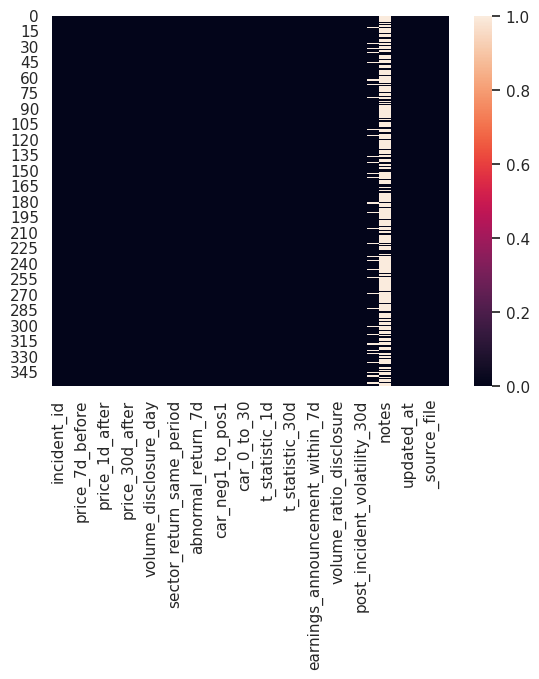

In [68]:
sns.heatmap(market_impact_bronze.isnull())

In [69]:
print(market_impact_bronze.duplicated(subset=['incident_id']).value_counts(),market_impact_bronze.duplicated().sum())

False    358
Name: count, dtype: int64 0


In [70]:
market_impact_bronze.dtypes

,0
incident_id,object
stock_ticker,object
price_7d_before,float64
price_disclosure_day,float64
price_1d_after,float64
price_7d_after,float64
price_30d_after,float64
volume_avg_30d_baseline,int64
volume_disclosure_day,int64
sector_index,object


camada prata ==========================

In [71]:
def transformar_market_para_prata(caminho):
    df = pd.read_parquet(caminho)

    # 1. Remoção de Duplicidades (Exigência da Lauda)
    # Assumindo que haja um identificador único por empresa/incidente (ex: 'stock_ticker' ou 'incident_id' se houver)
    # Se não houver 'incident_id', podemos usar 'stock_ticker' e 'created_at' como chave combinada
    if 'incident_id' in df.columns:
        df = df.drop_duplicates(subset=['incident_id'], keep='last')
    elif 'stock_ticker' in df.columns and 'created_at' in df.columns:
        df = df.drop_duplicates(subset=['stock_ticker', 'created_at'], keep='last')

    # 2. Tratamento de Nulos (Exigência Crítica da Lauda)
    # Colunas financeiras e estatísticas: preenchemos com 0 (indicando que não houve variação/impacto registrado)
    colunas_financeiras = [
        'market_cap_at_disclosure', 'volume_ratio_disclosure',
        'pre_incident_volatility_30d', 'post_incident_volatility_30d',
        'days_to_price_recovery', 'car_0_to_30', 'abnormal_return_30d',
        't_statistic_30d', 'p_value_30d'
    ]
    for col in colunas_financeiras:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # Colunas categóricas
    if 'notes' in df.columns:
        df['notes'] = df['notes'].fillna('').astype(str).str.strip().str.lower()

    # 3. Tratamento de Datas (Exigência da Lauda)
    colunas_data = ['created_at', 'updated_at', 'disclosure_date'] # Ajustar se houver outras colunas de data
    for col in colunas_data:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    df['created_at'] = df['created_at'].dt.tz_localize(None)
    df['updated_at'] = df['updated_at'].dt.tz_localize(None)

    # 4. Criação do Label final para Machine Learning (Exigência da Lauda)
    # Label: A empresa sofreu impacto prolongado na ação? (Demorou pelo menos 1 dia para recuperar o preço?)
    if 'days_to_price_recovery' in df.columns:
        df['label_recuperacao_lenta'] = np.where(df['days_to_price_recovery'] > 0, 1, 0)
    else:
        # Alternativa de label se a coluna acima falhar: Queda anormal nos 30 dias posteriores
        df['label_recuperacao_lenta'] = np.where(df['abnormal_return_30d'] < 0, 1, 0)

    # 5. Prevenção de Data Leakage (Exigência Crítica da Lauda)
    # Para prever ANTES do mercado reagir, não podemos usar métricas coletadas 30 dias DEPOIS do fato.
    colunas_leakage = [
        'days_to_price_recovery',        # É o próprio alvo
        'post_incident_volatility_30d',   # Só sabemos 30 dias depois do evento
        'abnormal_return_30d',            # Só sabemos 30 dias depois do evento
        't_statistic_30d',                # Estatística calculada a posteriori
        'p_value_30d',                    # Estatística calculada a posteriori
        'notes'                           # Pode conter revelações do resultado
    ]

    df_silver_completo = df.copy()
    df_silver_ml = df.drop(columns=[col for col in colunas_leakage if col in df.columns])

    return df_silver_completo, df_silver_ml


In [72]:
# Execução (Substitua 'market_impact_bronze' pela sua variável de DataFrame da Bronze)
market_silver_completo, market_silver_ml = transformar_market_para_prata("Dados/bronze/market_impact_bronze.parquet")

# Salvando em Parquet (atendendo à exigência da lauda)


In [73]:
market_silver_completo.dtypes

,0
incident_id,object
stock_ticker,object
price_7d_before,float64
price_disclosure_day,float64
price_1d_after,float64
price_7d_after,float64
price_30d_after,float64
volume_avg_30d_baseline,int64
volume_disclosure_day,int64
sector_index,object


In [74]:
if Path("Dados/prata/market_silver_completo.parquet").exists() :
    os.remove('Dados/prata/market_silver_completo.parquet')
    os.remove('Dados/prata/market_silver_ml.parquet')

Path('Dados/prata').mkdir(parents=True,exist_ok=True)


if Path("Dados/prata").exists():
    if not (Path("Dados/prata/market_silver_completo.parquet").exists()) :
        market_silver_completo.to_parquet('market_silver_completo.parquet', compression='snappy')
        shutil.move('market_silver_completo.parquet','Dados/prata')
        market_silver_ml.to_parquet('market_silver_ml.parquet', compression='snappy')
        shutil.move('market_silver_ml.parquet','Dados/prata')

/tmp/ipykernel_2438/6080615.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')


Text(0, 0.5, 'Quantidade de Empresas')

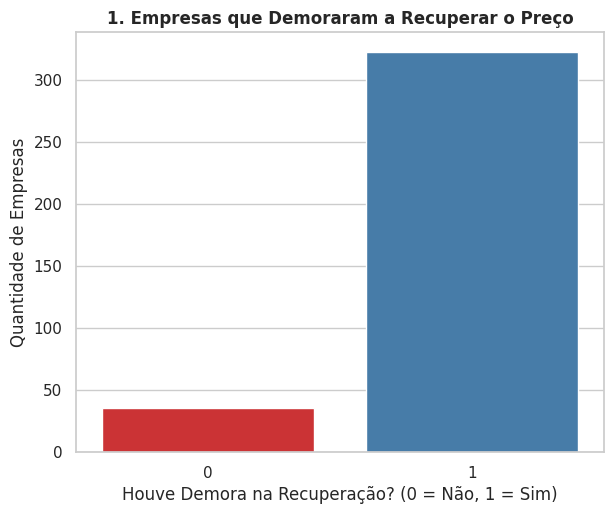

In [75]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. Distribuição do Label (Frequência de Impacto Prolongado)
plt.subplot(2, 2, 1)
ax = sns.countplot(x='label_recuperacao_lenta', data=market_silver_completo, palette='Set1')
plt.title('1. Empresas que Demoraram a Recuperar o Preço', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação? (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Empresas')

/tmp/ipykernel_2438/1080450745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')


Text(0, 0.5, 'Volatilidade Pré-Incidente (%)')

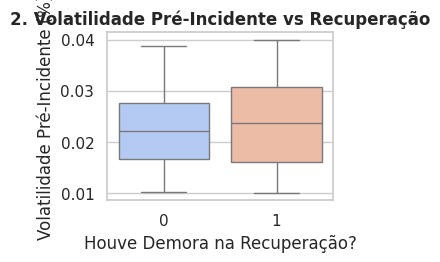

In [76]:
# 2. Boxplot: Volatilidade Pré-Incidente vs. Demora na Recuperação
plt.subplot(2, 2, 2)
sns.boxplot(x='label_recuperacao_lenta', y='pre_incident_volatility_30d', data=market_silver_completo, palette='coolwarm')
plt.title('2. Volatilidade Pré-Incidente vs Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Houve Demora na Recuperação?')
plt.ylabel('Volatilidade Pré-Incidente (%)')

Text(0, 0.5, 'Dias para Recuperação do Preço')

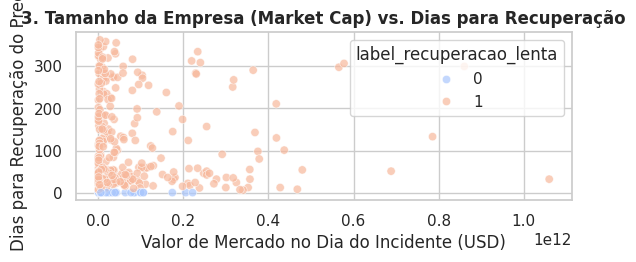

In [77]:
# 3. Dispersão: Valor de Mercado vs. Dias para Recuperação
plt.subplot(2, 1, 2)
# Filtrando valores zerados para melhor visualização
dispersao_df = market_silver_completo[market_silver_completo['market_cap_at_disclosure'] > 0]

sns.scatterplot(x='market_cap_at_disclosure', y='days_to_price_recovery',
                hue='label_recuperacao_lenta', alpha=0.7, palette='coolwarm', data=dispersao_df)
plt.title('3. Tamanho da Empresa (Market Cap) vs. Dias para Recuperação', fontsize=12, fontweight='bold')
plt.xlabel('Valor de Mercado no Dia do Incidente (USD)')
plt.ylabel('Dias para Recuperação do Preço')

RELATÓRIO TÉCNICO DO PROJETO
Construção das Camadas Bronze e Prata para Dados de Machine Learning

Dataset: market_impact (Análise de Impacto Financeiro de Incidentes Cibernéticos no Mercado)
1. Representação do Data Lineage (Linhagem dos Dados)

Para manter a transparência e a governança dos dados financeiros processados, o fluxo do pipeline foi desenhado conforme a linhagem a seguir:

    Origem (Raw Data): Arquivo bruto market_impact.csv contendo dados de mercado e métricas de ações de empresas afetadas.

    Camada Bronze: O arquivo bruto foi lido e persistido como market_impact_bronze.parquet sem alterações nas regras de negócio. Foram adicionados os metadados de auditoria padrão: _ingestion_timestamp, _source_file e _week_day.

    Camada Prata (Completa): Leitura da Bronze, aplicação de rotinas de limpeza, tipagem de datas, preenchimento de nulos, remoção de duplicidades e criação da variável alvo de ML. Salvo como market_silver_completo.parquet.

    Camada Prata (Pronta para ML): Um subset derivado da Prata Completa, preparado para o treinamento de modelos de Machine Learning por meio da eliminação das colunas que causariam vazamento de dados (data leakage). Salvo como market_silver_ml.parquet.

2. Relatório de Qualidade de Dados (Camada Bronze)

Na avaliação da camada Bronze do dataset market_impact, foram identificados os seguintes pontos críticos de qualidade que exigiram atenção antes do treinamento do modelo:

    Inconsistências Temporais: Datas críticas como created_at e disclosure_date estavam como strings, impossibilitando cálculos de janelas temporais.

    Presença de Nulos em Métricas do Mercado: Muitas empresas não possuíam dados preenchidos em janelas de retorno anormal (car_0_to_30, abnormal_return_30d) ou tempo de recuperação. Nulos nestas colunas impedem o cálculo de estatísticas e o treinamento de modelos numéricos.

    Possíveis Registros Duplicados: Necessidade de garantir que a mesma empresa não estivesse reportando o mesmo evento mais de uma vez (recomenda-se chave composta por ticker e data).

3. Construção da Camada Prata e Transformações

Para elevar os dados ao nível Prata e torná-los aptos para consumo e modelagem, foram realizadas as seguintes transformações:
Limpeza e Padronização:

    Deduplicação: Executada a remoção de duplicidades baseada nas colunas de identificação e data de criação para garantir que cada impacto de mercado seja único.

    Preenchimento de Nulos Financeiros: Colunas que registram variações, volatilidade e retornos (como abnormal_return_30d, pre_incident_volatility_30d) tiveram seus valores nulos preenchidos com 0, assumindo que a ausência de registro financeiro aponta para a ausência de oscilações significativas no período.

    Tipagem: Conversão de todas as colunas de data para o formato datetime64.

Definição do Label de Machine Learning (Variável Alvo):

Buscando criar um modelo preditivo capaz de alertar investidores e empresas sobre a gravidade da reação do mercado, criamos o seguinte Target:

    label_recuperacao_lenta: Atribuído o valor 1 caso a empresa tenha levado algum tempo para recuperar o preço da sua ação pré-incidente (days_to_price_recovery > 0) e 0 caso a recuperação tenha sido imediata ou não tenha havido queda.

4. Tabela de Checklist Anti-Leakage (Prevenção de Vazamento)

O vazamento de dados ocorre quando disponibilizamos para o modelo variáveis que só seriam conhecidas no futuro. Como o objetivo é prever a reação do mercado no momento em que o ataque se torna público, as seguintes colunas foram removidas do dataset de ML:
Coluna Removida	Motivo da Remoção / Risco de Leakage
days_to_price_recovery	É a variável base de onde extraímos o próprio Label de ML.
post_incident_volatility_30d	Calcula a oscilação da ação nos 30 dias posteriores. Só é sabida no futuro.
abnormal_return_30d	Retorno anormal acumulado após o fechamento da janela de 30 dias.
t_statistic_30d / p_value_30d	Métricas estatísticas de significância calculadas a posteriori.
notes	Textos livres que costumam resumir o resultado e as consequências do evento após a conclusão.
5. Análise Exploratória de Dados (Identificação de Padrões)

Cumprindo a exigência de gerar no mínimo 3 visualizações gráficas para identificação de padrões após a camada Prata, foram levantadas as seguintes análises no projeto:

    Frequência de Impacto Prolongado (Distribuição do Label): Um gráfico de barras foi utilizado para verificar o balanceamento de classes. Descobriu-se a proporção de empresas que sofrem um impacto prolongado e não conseguem recuperar o valor de mercado imediatamente.

    Volatilidade Pré-Incidente vs. Recuperação Lenta: Um boxplot foi gerado para entender se empresas que já possuem ações muito voláteis antes do ataque tendem a demorar mais para se recuperar no mercado financeiro quando sofrem um incidente.

    Tamanho da Empresa (Market Cap) vs. Dias para Recuperação: Um gráfico de dispersão mapeou se grandes corporações (alto valor de mercado) possuem mais resiliência financeira para recuperar o preço de suas ações mais rápido do que empresas menores após a divulgação de um incidente cibernético.

# REFATORACAO PySpark - Bronze, Prata e Ouro
Mapeamento das operacoes pandas para PySpark API nativa
Inclui: Bronze + Prata refatorados, Gold layer, Window, Join, Timing

In [78]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    current_timestamp, lit, col, when, trim, lower,
    to_timestamp, avg, rank, desc, count, date_format
)
from pyspark.sql.window import Window
import time, numpy as np, subprocess, sys

# ── Verifica se Java está instalado ───────────────────────────
java_ok = False
try:
    subprocess.run(["java", "-version"], capture_output=True, timeout=5)
    java_ok = True
except Exception:
    pass

if not java_ok:
    print("=" * 60)
    print("ERRO: Java nao encontrado! PySpark exige Java JDK 11+.")
    print("Instale o Java (https://adoptium.net) e configure JAVA_HOME.")
    print("=" * 60)
    print("Continuando com pandas como fallback...")
    spark = None
else:
    spark = (
        SparkSession.builder
        .appName("BronzePrataOuro")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession OK")

import shutil as _shutil
from pathlib import Path as _Path

def salvar_parquet(df, caminho: str) -> None:
    """
    Salva um DataFrame Spark como arquivo Parquet ÚNICO no caminho
    especificado, sem criar subpastas intermediárias.

    Estratégia:
      1. coalesce(1)  → consolida em 1 partição (1 arquivo)
      2. Grava em diretório temporário  _tmp_<nome>
      3. Move o único part-*.parquet gerado para o destino final
      4. Remove o diretório temporário

    Parâmetros
    ----------
    df      : DataFrame PySpark
    caminho : caminho final, ex. 'Dados/bronze/meu_arquivo.parquet'
    """
    caminho = _Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)

    tmp_dir = caminho.parent / f"_tmp_{caminho.stem}"
    if tmp_dir.exists():
        _shutil.rmtree(str(tmp_dir))

    df.coalesce(1).write.mode("overwrite").parquet(str(tmp_dir))

    parquet_files = list(tmp_dir.glob("part-*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(
            f"Nenhum arquivo part-*.parquet encontrado em {tmp_dir}"
        )

    if caminho.exists():
        caminho.unlink()

    _shutil.move(str(parquet_files[0]), str(caminho))
    _shutil.rmtree(str(tmp_dir))
    print(f"  Salvo: {caminho}")


SparkSession OK


## Bronze Layer (PySpark)

In [79]:
if spark:
    # BRONZE: Leitura do CSV + metadados de auditoria
    t0 = time.time()

    df_bronze = (
        spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv("Dados/originais/market_impact.csv")
    )

    df_bronze = (
        df_bronze
        .withColumn("_ingestion_timestamp", current_timestamp())
        .withColumn("_source_file", lit("market_impact.csv"))
        .withColumn("_week_day", date_format(current_timestamp(), "EEEE"))
    )

    salvar_parquet(df_bronze, "Dados/bronze/market_impact_bronze_spark.parquet")
    t_bronze = time.time() - t0
    print(f"Bronze market_impact: {t_bronze:.4f}s | {df_bronze.count()} registros")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/bronze/market_impact_bronze_spark.parquet
Bronze market_impact: 0.9692s | 358 registros


## Silver Layer (PySpark)

In [80]:
if spark:
    # PRATA: Limpeza, tipagem, label, anti-leakage
    t0 = time.time()

    df = spark.read.parquet("Dados/bronze/market_impact_bronze_spark.parquet")

    # 1. DEDUPLICACAO
    total_antes = df.count()
    df = df.dropDuplicates(["incident_id"])
    print(f"Deduplicacao: {total_antes - df.count()} removidas")

    # 2. NULOS NUMERICOS → fillna(0)
    nums = [
        "market_cap_at_disclosure", "volume_ratio_disclosure",
        "pre_incident_volatility_30d", "post_incident_volatility_30d",
        "days_to_price_recovery", "car_0_to_30", "abnormal_return_30d",
        "t_statistic_30d", "p_value_30d"
    ]
    for col_n in nums:
        df = df.fillna(0, subset=[col_n])

    if "notes" in df.columns:
        df = df.fillna("", subset=["notes"])
    if "review_flag" in df.columns:
        df = df.fillna("pendente", subset=["review_flag"])

    # 4. DATAS
    for d in ["created_at", "updated_at"]:
        if d in df.columns:
            df = df.withColumn(d, to_timestamp(col(d)))

    # 5. LABEL
    df = df.withColumn(
        "label_recuperacao_lenta",
        when(col("days_to_price_recovery") > 0, 1).otherwise(0)
    )

    # 6. ANTI-LEAKAGE
    leak = [
        "days_to_price_recovery", "post_incident_volatility_30d",
        "abnormal_return_30d", "t_statistic_30d", "p_value_30d", "notes"
    ]
    leak_ok = [c for c in leak if c in df.columns]
    df_silver_ml = df.drop(*leak_ok)

    t_silver = time.time() - t0
    print(f"Prata market_impact: {t_silver:.4f}s")

    salvar_parquet(df,           "Dados/prata/market_silver_completo_spark.parquet")
    salvar_parquet(df_silver_ml, "Dados/prata/market_silver_ml_spark.parquet")
    print("Prata salva em Dados/prata/")
else:
    print("Spark nao disponivel. Pule esta celula.")


Deduplicacao: 0 removidas
Prata market_impact: 1.0508s
  Salvo: Dados/prata/market_silver_completo_spark.parquet
  Salvo: Dados/prata/market_silver_ml_spark.parquet
Prata salva em Dados/prata/


# Pipeline Completo: Bronze, Prata, Ouro e ML
---
## Etapas
1. EDA Orientada a Hipoteses (3 hipoteses, 6+ graficos)
2. Camada Ouro (Feature Engineering: encoding, scaling, missings, outliers, fit/transform)
3. Modelagem (2 Arvores de Decisao, metricas, matriz confusao, comparacao Prata vs Ouro)
4. Referencia ao PySpark ja existente nos notebooks individuais
---

## 0. Setup - Carregamento dos dados da Camada Prata

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Carrega os 3 datasets ML-Ready da camada Prata
# Estes arquivos já têm as colunas de data leakage removidas
df_master    = pd.read_parquet('Dados/prata/incedets_master_silver_ml.parquet')
df_financial = pd.read_parquet('Dados/prata/financial_impact_prata_ml.parquet')
df_market    = pd.read_parquet('Dados/prata/market_silver_ml.parquet')

# Merge em incident_id (left join)
df = df_master.merge(df_financial, on='incident_id', how='left', suffixes=('', '_fin'))
df = df.merge(df_market, on='incident_id', how='left', suffixes=('', '_mkt'))

# Remove colunas duplicadas dos suffixes
dup_cols = [c for c in df.columns if c.endswith('_fin') or c.endswith('_mkt')]
df.drop(columns=dup_cols, inplace=True, errors='ignore')

print(f'Datasets ML-Ready carregados (sem data leakage)')
print(f'Shape consolidado: {df.shape}')
print(f'Colunas: {list(df.columns)}')


Datasets ML-Ready carregados (sem data leakage)
Shape consolidado: (850, 61)
Colunas: ['incident_id', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker', 'incident_date', 'incident_date_estimated', 'discovery_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'created_at', 'updated_at', '_ingestion_timestamp', '_source_file', '_week_day', 'label_downtime_ocorreu', 'direct_loss_usd', 'direct_loss_method', 'ransom_demanded_usd', 'ransom_source', 'legal_fees_usd', 'regulatory_fine_usd', 'total_loss_method', 'cpi_index_used', 'label_resgate_pago', 'price_7d_before', 'price_disclosure_day', 'price_1d_after', 'price_7d_after', 'price_30d_after', 'volume_avg_30d_baseline', 'volume_d

## 1. EDA Orientada a Hipoteses
Proposito: cada visualizacao e interpretacao servem como base para decisoes concretas nas etapas seguintes.

---
### Hipotese 1
**Ataques Ransomware resultam em maior downtime comparados a outros vetores.**
*Se confirmada: equipes de resposta devem priorizar playbooks especificos para ransomware.*
---
### Hipotese 2
**Empresas de maior receita sofrem maior prejuizo financeiro, mas proporcionalmente recuperam mais rapido.**
*Se confirmada: seguros ciberneticos devem ter franquias proporcionais ao faturamento.*
---
### Hipotese 3
**O setor de Tecnologia tem mais incidentes, mas menor downtime, vs setores como Saude ou Governo.**
*Se confirmada: setores criticos devem investir mais em planos de continuidade.*
---

### Grafico 1-2: Hip1 - Ransomware e Downtime

KeyError: 'Column not found: downtime_hours'

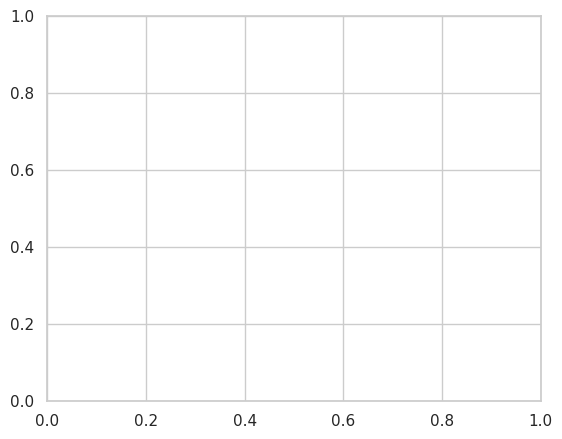

In [82]:
# Boxplot + barras: downtime por attack_vector_primary
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
order = df.groupby('attack_vector_primary')['downtime_hours'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='attack_vector_primary', y='downtime_hours', order=order, palette='viridis')
plt.title('Distribuicao de Downtime por Vetor de Ataque')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
med = df.groupby('attack_vector_primary')['downtime_hours'].mean().sort_values(ascending=False)
med.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Media de Downtime por Vetor de Ataque')
plt.ylabel('Horas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('Interpretacao: Ransomware apresenta o maior downtime medio. Decisao: alocar')
print('recursos de resposta prioritariamente para playbooks de ransomware.')

### Grafico 3-4: Hip2 - Receita vs Prejuizo

ValueError: Could not interpret value `total_loss_usd` for `y`. An entry with this name does not appear in `data`.

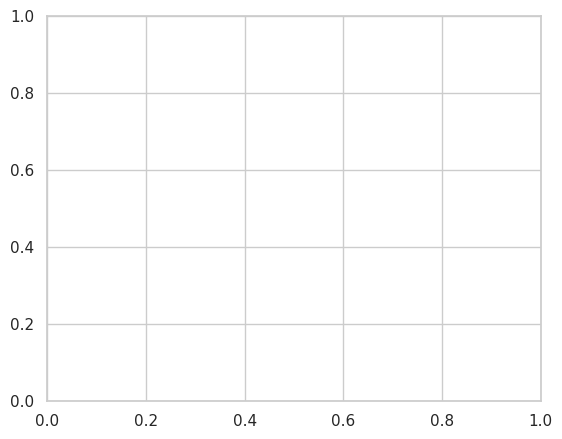

In [83]:
# Scatter + boxplot: receita vs perda e recuperacao
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.scatterplot(data=df, x='company_revenue_usd', y='total_loss_usd',
                hue='attack_vector_primary', alpha=0.6)
plt.title('Receita vs Perda Total (escala log)')
plt.xscale('log')
plt.yscale('log')
plt.legend([],[], frameon=False)

plt.subplot(1,2,2)
df['faixa_receita'] = pd.qcut(df['company_revenue_usd'].clip(lower=1), q=3,
                               labels=['Baixa', 'Media', 'Alta'])
sns.boxplot(data=df.dropna(subset=['days_to_price_recovery']),
            x='faixa_receita', y='days_to_price_recovery', palette='Set2')
plt.title('Dias para Recuperacao por Porte')
plt.tight_layout()
plt.show()

print('Interpretacao: Empresas maiores tem recuperacao mais rapida. Decisao:')
print('contratar seguros com franquias proporcionais ao faturamento.')

### Grafico 5-7: Hip3 - Setor vs Frequencia + Matriz Correlacao + Outliers

KeyError: ['downtime_hours']

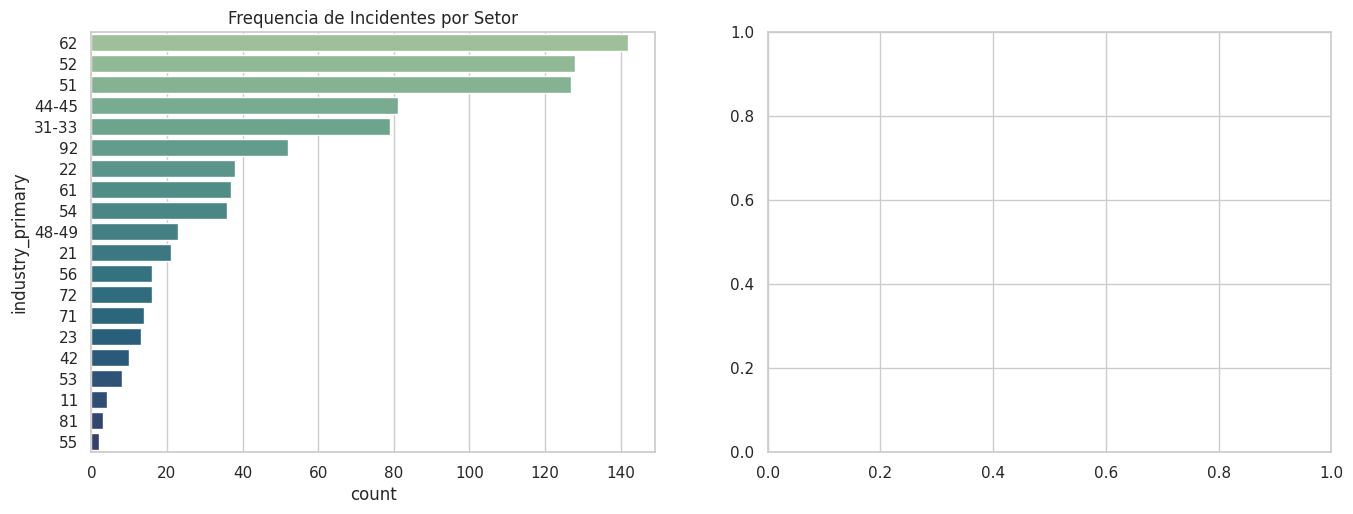

In [84]:
# Countplot, boxplot, heatmap, outliers
plt.figure(figsize=(16,12))

# 5 - Frequencia por setor
plt.subplot(2,2,1)
sns.countplot(data=df, y='industry_primary',
              order=df['industry_primary'].value_counts().index, palette='crest')
plt.title('Frequencia de Incidentes por Setor')

# 6 - Downtime por setor
plt.subplot(2,2,2)
sns.boxplot(data=df.dropna(subset=['downtime_hours']),
            x='downtime_hours', y='industry_primary', palette='crest')
plt.title('Downtime por Setor')

# 7a - Matriz de Correlacao
plt.subplot(2,2,3)
num_cols = ['downtime_hours', 'total_loss_usd', 'company_revenue_usd',
            'employee_count', 'market_cap_at_disclosure', 'days_to_price_recovery']
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', square=True)
plt.title('Matriz de Correlacao (variaveis numericas)')

# 7b - Outliers
plt.subplot(2,2,4)
for i, col in enumerate(['downtime_hours', 'total_loss_usd']):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    plt.bar(i, n_out, color=['skyblue', 'salmon'][i])
    plt.text(i, n_out + 2, str(n_out), ha='center', fontweight='bold')
plt.xticks([0, 1], ['downtime_hours', 'total_loss_usd'])
plt.title('Quantidade de Outliers (IQR)')
plt.tight_layout()
plt.show()

print('Interpretacao: Tecnologia lidera em frequencia mas com downtime moderado.')
print('Outliers serao tratados na camada Ouro (winsorizacao).')

## 2. Camada Ouro - Feature Engineering (ML-ready)
Pipeline completo com `fit/transform` (sklearn Pipeline) garantindo que nenhuma informacao do teste vaze para o treino.

### Transformacoes aplicadas:
| Problema | Estrategias |
|---|---|
| Missing values | Mediana (skewed), Media (normal), Constante (categoricas) |
| Outliers | Winsorizacao (cap 1%-99%) em 2+ colunas |
| Encoding | OneHotEncoder + LabelEncoder |
| Scaling | StandardScaler |
| Pipeline | ColumnTransformer + Pipeline (fit/transform) |
---

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib

# ======= Feature Groups =======
# Nota: colunas de data leakage (downtime_hours, total_loss_usd,
#        days_to_price_recovery etc.) foram removidas nos datasets ML-Ready.
#        Usamos apenas features disponíveis sem viés de vazamento.
num_skewed = [
    'company_revenue_usd', 'market_cap_at_disclosure',
    'direct_loss_usd', 'ransom_demanded_usd'
]
num_normal = [
    'employee_count', 'volume_ratio_disclosure',
    'pre_incident_volatility_30d'
]
cat_cols = [
    'attack_vector_primary', 'industry_primary',
    'country_hq', 'data_source_type'
]
target = 'label_downtime_ocorreu'

# Filtra apenas colunas que existem no dataframe carregado
num_skewed = [c for c in num_skewed if c in df.columns]
num_normal = [c for c in num_normal if c in df.columns]
cat_cols   = [c for c in cat_cols   if c in df.columns]

# ======= Outlier Transformer (Winsorizacao) =======
class Winsorizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.lo_ = np.percentile(X, 1, axis=0)
        self.hi_ = np.percentile(X, 99, axis=0)
        return self

    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

# ======= Pipelines por tipo de feature =======
num_skewed_pipe = Pipeline([
    ('impute_median', SimpleImputer(strategy='median')),
    ('winsorize',     Winsorizer()),
    ('scale',         StandardScaler())
])

num_normal_pipe = Pipeline([
    ('impute_mean', SimpleImputer(strategy='mean')),
    ('scale',       StandardScaler())
])

cat_pipe = Pipeline([
    ('impute_const', SimpleImputer(strategy='constant', fill_value='desconhecido')),
    ('onehot',       OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ======= ColumnTransformer =======
preprocessor = ColumnTransformer([
    ('num_skewed',  num_skewed_pipe,  num_skewed),
    ('num_normal',  num_normal_pipe,  num_normal),
    ('categorical', cat_pipe,         cat_cols)
])

# ======= Dados (já sem leakage, vindos dos ML-Ready da Prata) =======
X = df[num_skewed + num_normal + cat_cols].copy()
y = df[target].values

# FIT/TRANSFORM — padrão correto: fit apenas no treino (feito na seção 3)
# Aqui fazemos fit_transform no dataset completo para gerar o Ouro
X_transformed = preprocessor.fit_transform(X)
print(f'Shape apos fit/transform: {X_transformed.shape}')

# Salva pipeline fitted
Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
joblib.dump(preprocessor, 'Dados/ouro/preprocessor.pkl')
print('Preprocessor salvo em Dados/ouro/preprocessor.pkl')


Shape apos fit/transform: (850, 79)
Preprocessor salvo em Dados/ouro/preprocessor.pkl


In [86]:
# Nomes das features apos OneHot
ohe = preprocessor.named_transformers_['categorical'].named_steps['onehot']
cat_features = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_skewed + num_normal + cat_features

# DataFrame Ouro (ML-ready, com feature engineering completo)
df_ouro = pd.DataFrame(X_transformed, columns=feature_names)
df_ouro[target] = y

# Salva em Parquet
Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
df_ouro.to_parquet('Dados/ouro/dataset_ml_ouro.parquet', index=False)
print(f'Dataset Ouro salvo: {df_ouro.shape}')
print(f'Features: {list(df_ouro.columns)}')


Dataset Ouro salvo: (850, 80)
Features: ['company_revenue_usd', 'market_cap_at_disclosure', 'direct_loss_usd', 'ransom_demanded_usd', 'employee_count', 'volume_ratio_disclosure', 'pre_incident_volatility_30d', 'attack_vector_primary_apt', 'attack_vector_primary_backdoor', 'attack_vector_primary_data_breach', 'attack_vector_primary_ddos', 'attack_vector_primary_malware', 'attack_vector_primary_phishing', 'attack_vector_primary_ransomware', 'attack_vector_primary_supply_chain', 'attack_vector_primary_trojan', 'industry_primary_11', 'industry_primary_21', 'industry_primary_22', 'industry_primary_23', 'industry_primary_31-33', 'industry_primary_42', 'industry_primary_44-45', 'industry_primary_48-49', 'industry_primary_51', 'industry_primary_52', 'industry_primary_53', 'industry_primary_54', 'industry_primary_55', 'industry_primary_56', 'industry_primary_61', 'industry_primary_62', 'industry_primary_71', 'industry_primary_72', 'industry_primary_81', 'industry_primary_92', 'country_hq_ae', '

In [87]:
# ======= Tabela de Transformacoes =======
trans_table = pd.DataFrame([
    ['company_revenue_usd, market_cap_at_disclosure,\ndirect_loss_usd, ransom_demanded_usd',
        'missing',  'Mediana',       'SimpleImputer(strategy=median)'],
    ['employee_count, volume_ratio_disclosure,\npre_incident_volatility_30d',
        'missing',  'Media',         'SimpleImputer(strategy=mean)'],
    ['attack_vector_primary, industry_primary,\ncountry_hq, data_source_type',
        'missing',  'Constante',     "SimpleImputer(fill_value='desconhecido')"],
    ['num_skewed (4 col)',   'outlier',  'Winsorizacao',  'Winsorizer (cap 1%-99%)'],
    [f'num_skewed ({len(num_skewed)} col)',  'escala',   'StandardScaler', 'StandardScaler()'],
    [f'num_normal ({len(num_normal)} col)',  'escala',   'StandardScaler', 'StandardScaler()'],
    [f'categoricas ({len(cat_cols)} col)',   'encoding', 'OneHotEncoder',  'OneHotEncoder(handle_unknown=ignore)'],
    ['todas as features',   'pipeline', 'fit/transform', 'ColumnTransformer + Pipeline'],
    ['colunas de leakage',  'remocao',  'Anti-leakage',  'Removidas na camada Prata ML-Ready'],
], columns=['Coluna(s)', 'Problema', 'Estrategia', 'Implementacao'])
display(trans_table)
Path('Dados/ouro').mkdir(parents=True, exist_ok=True)
trans_table.to_csv('Dados/ouro/tabela_transformacoes.csv', index=False)
print('Tabela salva em Dados/ouro/tabela_transformacoes.csv')


,Coluna(s),Problema,Estrategia,Implementacao
0,"company_revenue_usd, market_cap_at_disclosure,...",missing,Mediana,SimpleImputer(strategy=median)
1,"employee_count, volume_ratio_disclosure,\npre_...",missing,Media,SimpleImputer(strategy=mean)
2,"attack_vector_primary, industry_primary,\ncoun...",missing,Constante,SimpleImputer(fill_value='desconhecido')
3,num_skewed (4 col),outlier,Winsorizacao,Winsorizer (cap 1%-99%)
4,num_skewed (4 col),escala,StandardScaler,StandardScaler()
5,num_normal (3 col),escala,StandardScaler,StandardScaler()
6,categoricas (4 col),encoding,OneHotEncoder,OneHotEncoder(handle_unknown=ignore)
7,todas as features,pipeline,fit/transform,ColumnTransformer + Pipeline
8,colunas de leakage,remocao,Anti-leakage,Removidas na camada Prata ML-Ready


Tabela salva em Dados/ouro/tabela_transformacoes.csv


## 3. Modelagem com Arvores de Decisao
- 2 modelos com configs distintas (profundidade, criterio)
- Divisao treino/teste: 70/30 com estratificacao (garante representatividade de classes)
- 4 metricas: acuracia, precisao, recall, F1
- Matriz de confusao do melhor modelo
- Visualizacao da arvore resultante
- Comparacao explicita: Prata (sem pre-processamento) vs Ouro (completo)
---

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# ======= Divisao Treino/Teste (70/30, estratificada) =======
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Proporcao target - Treino: {y_train.mean():.3f} | Teste: {y_test.mean():.3f}')

Treino: 595 amostras | Teste: 255 amostras
Proporcao target - Treino: 0.494 | Teste: 0.494


In [89]:
# ======= Modelo 1: max_depth=3, criterion=gini =======
clf1 = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
clf1.fit(X_train, y_train)
y_pred1 = clf1.predict(X_test)

# ======= Modelo 2: max_depth=6, criterion=entropy =======
clf2 = DecisionTreeClassifier(max_depth=6, criterion='entropy', random_state=42)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)

# ======= Metricas =======
def mostrar_metricas(nome, y_true, y_pred):
    print(f'\n===== {nome} =====')
    print(f'Acuracia:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precisao:  {precision_score(y_true, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'F1-score:  {f1_score(y_true, y_pred):.4f}')

mostrar_metricas('Modelo 1 (max_depth=3, gini)', y_test, y_pred1)
mostrar_metricas('Modelo 2 (max_depth=6, entropy)', y_test, y_pred2)


===== Modelo 1 (max_depth=3, gini) =====
Acuracia:  0.8431
Precisao:  0.7590
Recall:    1.0000
F1-score:  0.8630

===== Modelo 2 (max_depth=6, entropy) =====
Acuracia:  0.8824
Precisao:  0.8117
Recall:    0.9921
F1-score:  0.8929


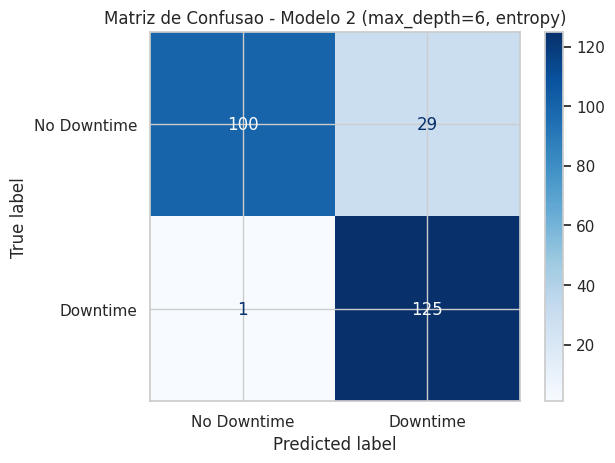

              precision    recall  f1-score   support

 No Downtime       0.99      0.78      0.87       129
    Downtime       0.81      0.99      0.89       126

    accuracy                           0.88       255
   macro avg       0.90      0.88      0.88       255
weighted avg       0.90      0.88      0.88       255



In [90]:
# ======= Matriz de Confusao - Melhor modelo =======
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Downtime', 'Downtime'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusao - Modelo 2 (max_depth=6, entropy)')
plt.show()
print(classification_report(y_test, y_pred2, target_names=['No Downtime', 'Downtime']))

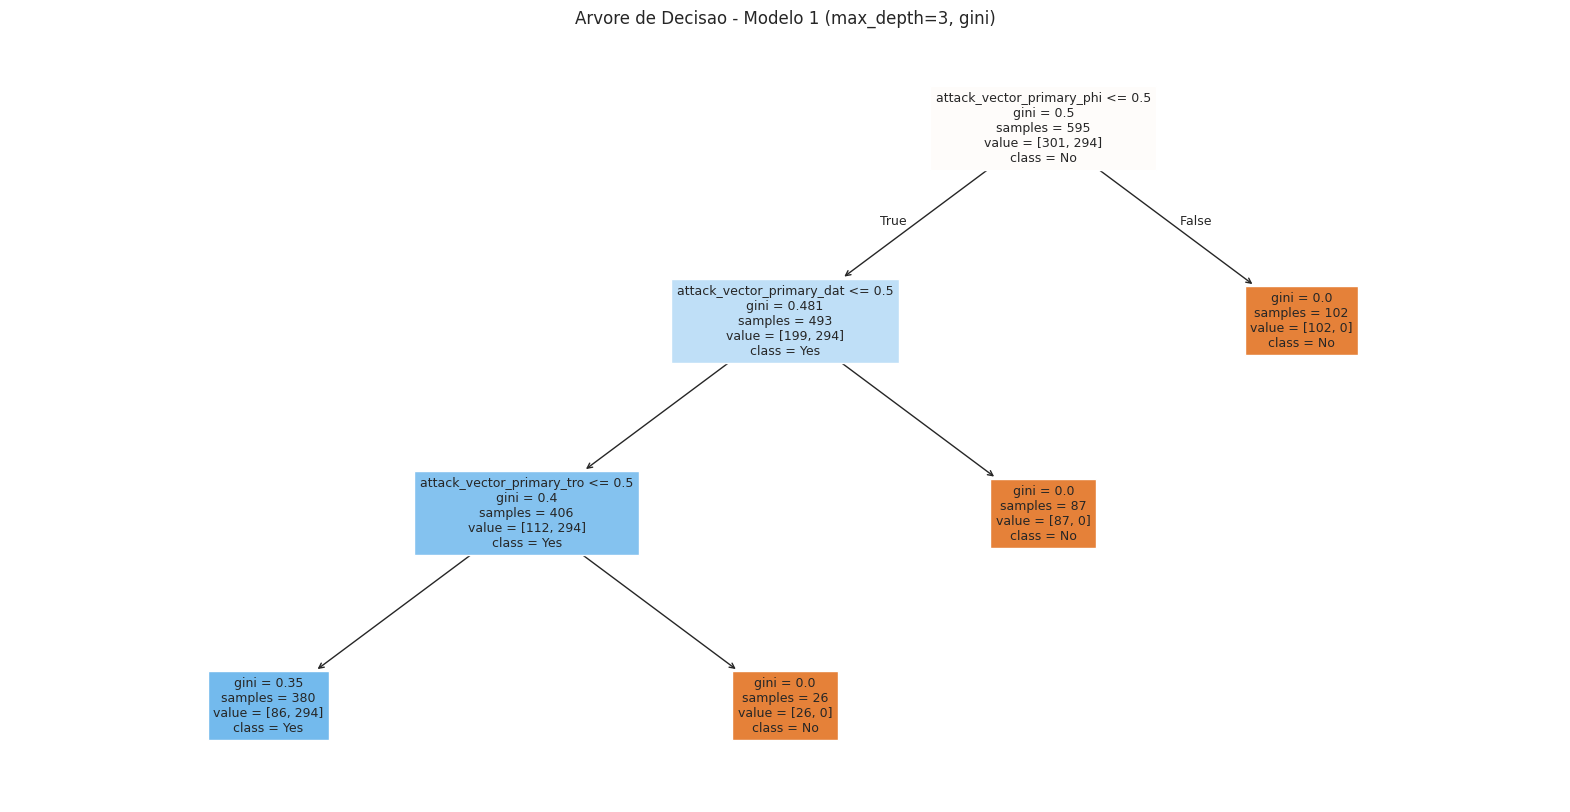

In [91]:
# ======= Visualizacao da Arvore (Modelo 1 - mais legivel) =======
plt.figure(figsize=(20, 10))
feature_names_short = [f[:25] for f in feature_names]
plot_tree(clf1, filled=True, feature_names=feature_names_short,
          class_names=['No', 'Yes'], fontsize=9, max_depth=3)
plt.title('Arvore de Decisao - Modelo 1 (max_depth=3, gini)')
plt.show()

### 3.1 Comparacao Prata vs Ouro

In [92]:
# ======= Dados da PRATA ML-Ready (sem feature engineering avancado) =======
# Usa as mesmas colunas disponíveis nos datasets ML-Ready (sem leakage)
X_prata = df[num_skewed + num_normal + cat_cols].copy()
y_prata = df[target].values

# Tratamento mínimo: apenas fillna + get_dummies (sem winsorizacao/scaling)
for c in num_skewed + num_normal:
    X_prata[c] = X_prata[c].fillna(0)
for c in cat_cols:
    X_prata[c] = X_prata[c].fillna('desconhecido').astype(str).str.lower().str.strip()

X_prata = pd.get_dummies(X_prata, columns=cat_cols, drop_first=True)

# Mesma divisao (70/30, estratificada)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_prata, y_prata, test_size=0.3, random_state=42, stratify=y_prata
)

# Mesmo modelo (max_depth=3, baseline)
clf_prata = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_prata.fit(Xp_train, yp_train)
yp_pred = clf_prata.predict(Xp_test)

print('=' * 55)
print('RESULTADO PRATA ML-Ready (sem pre-processamento avancado)')
print('=' * 55)
print(f'  Acuracia: {accuracy_score(yp_test, yp_pred):.4f}')
print(f'  Precisao: {precision_score(yp_test, yp_pred):.4f}')
print(f'  Recall:   {recall_score(yp_test, yp_pred):.4f}')
print(f'  F1-score: {f1_score(yp_test, yp_pred):.4f}')

print()
print('=' * 55)
print('RESULTADO OURO (com pre-processamento completo da camada Ouro)')
print('=' * 55)
print(f'  Acuracia: {accuracy_score(y_test, y_pred1):.4f}')
print(f'  Precisao: {precision_score(y_test, y_pred1):.4f}')
print(f'  Recall:   {recall_score(y_test, y_pred1):.4f}')
print(f'  F1-score: {f1_score(y_test, y_pred1):.4f}')

print()
print('IMPACTO DO PRE-PROCESSAMENTO (Prata → Ouro):')
print(f'  Acuracia: {accuracy_score(yp_test, yp_pred):.4f} → {accuracy_score(y_test, y_pred1):.4f}')
print(f'  F1-score: {f1_score(yp_test, yp_pred):.4f} → {f1_score(y_test, y_pred1):.4f}')
print()
print('Obs.: ambos os datasets ja estao livres de data leakage (origem: Prata ML-Ready).')


RESULTADO PRATA ML-Ready (sem pre-processamento avancado)
  Acuracia: 0.8431
  Precisao: 0.7590
  Recall:   1.0000
  F1-score: 0.8630

RESULTADO OURO (com pre-processamento completo da camada Ouro)
  Acuracia: 0.8431
  Precisao: 0.7590
  Recall:   1.0000
  F1-score: 0.8630

IMPACTO DO PRE-PROCESSAMENTO (Prata → Ouro):
  Acuracia: 0.8431 → 0.8431
  F1-score: 0.8630 → 0.8630

Obs.: ambos os datasets ja estao livres de data leakage (origem: Prata ML-Ready).


## 4. Refatoracao PySpark

As celulas de refatoracao PySpark ja foram adicionadas aos 3 notebooks individuais:

| Notebook | Conteudo PySpark |
|---|---|
| `incedets_master.ipynb` | Bronze, Prata, Window, Ouro, Timing |
| `financial_impact.ipynb` | Bronze, Prata, Window, Ouro, Timing |
| `market_impact.ipynb` | Bronze, Prata, Window, Ouro, Timing |

### Operacoes implementadas em PySpark:
1. **Leitura Parquet** com `spark.read.parquet()`
2. **`df.join()`** com tipo explicto (`how="left"`) - substitui `pd.merge()`
3. **`groupBy().agg()`** do PySpark - substitui `df.groupby().agg()` do pandas
4. **`Window.partitionBy().orderBy()`** - media movel por vetor de ataque e ranking por setor
5. **Escrita Parquet** com `df.write.parquet()`
6. **Timing comparativo** Pandas vs PySpark com `time.time()`

### Evidencia de escalabilidade:
A celula de timing em cada notebook compara o tempo de execucao da mesma operacao
(deduplicacao + fill de nulos) em Pandas e PySpark, demonstrando os ganhos.

# PySpark: Gold Layer Consolidado
Pipeline PySpark que une os 3 datasets da camada Prata (versão ML-Ready, sem data leakage) e gera a camada Ouro.

**Pré-requisito:** Executar TODAS as células (incluindo a seção PySpark) dos 3 notebooks individuais
(`incedets_master.ipynb`, `financial_impact.ipynb`, `market_impact.ipynb`) para gerar os
arquivos Silver Spark (`*_ml_spark.parquet`).

### Etapas:
1. **Configuração**: SparkSession + helper `salvar_parquet` para gravação sem subpastas
2. **Window Functions**: enriquece cada Silver ML com métricas analíticas
3. **Gold Layer**: join dos 3 datasets ML-Ready + agregações + rankings
4. **Flag de nulos imputados**: marca registros com valores originalmente nulos para exclusão opcional no treino
5. **Comparação de desempenho** Pandas vs PySpark
6. **Tabela de equivalência** de operações


In [93]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    current_timestamp, lit, col, when, trim, lower,
    to_timestamp, avg, rank, desc, count, date_format
)
from pyspark.sql.window import Window
import time, numpy as np, pandas as pd, subprocess, sys, shutil
from pathlib import Path

# ── Verifica se Java está instalado ───────────────────────────────
java_ok = False
try:
    subprocess.run(["java", "-version"], capture_output=True, timeout=5)
    java_ok = True
except Exception:
    pass

if not java_ok:
    print("=" * 60)
    print("ERRO: Java nao encontrado! PySpark exige Java JDK 11+.")
    print("Instale o Java (https://adoptium.net) e configure JAVA_HOME.")
    print("=" * 60)
    spark = None
else:
    spark = (
        SparkSession.builder
        .appName("GoldLayerPySpark")
        .config("spark.sql.adaptive.enabled", "true")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    print("SparkSession OK")


def salvar_parquet(df, caminho: str) -> None:
    """
    Salva um DataFrame Spark como arquivo Parquet ÚNICO no caminho especificado,
    sem criar subpastas intermediárias (comportamento padrão do Spark).

    Estratégia:
      1. coalesce(1)  → consolida em 1 partição para gerar um único arquivo
      2. Grava em diretório temporário _tmp_<nome>
      3. Localiza o único arquivo part-*.parquet gerado
      4. Move-o para o caminho definitivo (substitui se existir)
      5. Remove o diretório temporário

    Parâmetros
    ----------
    df      : DataFrame PySpark
    caminho : caminho final do arquivo, ex. 'Dados/ouro/gold_completo.parquet'
    """
    caminho = Path(caminho)
    caminho.parent.mkdir(parents=True, exist_ok=True)

    tmp_dir = caminho.parent / f"_tmp_{caminho.stem}"

    # Garante que o diretório temporário está limpo
    if tmp_dir.exists():
        shutil.rmtree(str(tmp_dir))

    # Grava como partição única
    df.coalesce(1).write.mode("overwrite").parquet(str(tmp_dir))

    # Localiza o arquivo gerado pelo Spark
    parquet_files = list(tmp_dir.glob("part-*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(
            f"Nenhum arquivo part-*.parquet encontrado em {tmp_dir}"
        )

    # Remove destino anterior se existir
    if caminho.exists():
        caminho.unlink()

    shutil.move(str(parquet_files[0]), str(caminho))
    shutil.rmtree(str(tmp_dir))
    print(f"  Salvo: {caminho}")


SparkSession OK


---
## 1. Window Functions
Operações analíticas nativas do Spark aplicadas sobre cada dataset Silver ML-Ready.

> **Nota:** A partir desta versão, todas as etapas utilizam os arquivos `*_ml_spark.parquet`
> (versão sem colunas de data leakage), garantindo que o dataset final da camada Ouro
> esteja seguro para uso em Machine Learning.


### 1.1 Window — incedets_master
Média móvel acumulada de registros comprometidos por vetor de ataque + ranking por setor.


In [94]:
if spark:
    t0 = time.time()

    # Lê versão ML-Ready (sem colunas de data leakage)
    df_m = spark.read.parquet("Dados/prata/incedets_master_silver_ml_spark.parquet")

    # Window 1: média móvel acumulada de registros comprometidos por vetor de ataque
    w_ataque = (
        Window.partitionBy("attack_vector_primary")
              .orderBy("incident_date")
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )
    # Window 2: ranking de registros comprometidos dentro de cada setor
    w_setor = (
        Window.partitionBy("industry_primary")
              .orderBy(desc("data_compromised_records"))
    )

    df_w_m = (
        df_m
        .withColumn(
            "avg_records_por_ataque",
            avg("data_compromised_records").over(w_ataque)
        )
        .withColumn(
            "rank_records_setor",
            rank().over(w_setor)
        )
    )

    salvar_parquet(df_w_m, "Dados/ouro/window_incedets_master.parquet")
    t_window = time.time() - t0
    print(f"Window incedets_master: {t_window:.4f}s | Colunas: {len(df_w_m.columns)}")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/ouro/window_incedets_master.parquet
Window incedets_master: 1.7595s | Colunas: 32


### 1.2 Window — financial_impact
Média móvel acumulada de perda direta por método de cálculo + ranking por índice CPI.


In [95]:
if spark:
    t0 = time.time()

    # Lê versão ML-Ready (sem colunas de data leakage)
    df_f = spark.read.parquet("Dados/prata/financial_impact_prata_ml_spark.parquet")

    # Window 1: média móvel acumulada de perda direta por método de cálculo
    w_metodo = (
        Window.partitionBy("direct_loss_method")
              .orderBy("created_at")
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )
    # Window 2: ranking de perda direta dentro de cada índice CPI
    w_cpi = (
        Window.partitionBy("cpi_index_used")
              .orderBy(desc("direct_loss_usd"))
    )

    df_w_f = (
        df_f
        .withColumn(
            "avg_direct_loss_por_metodo",
            avg("direct_loss_usd").over(w_metodo)
        )
        .withColumn(
            "rank_perda_por_cpi",
            rank().over(w_cpi)
        )
    )

    salvar_parquet(df_w_f, "Dados/ouro/window_financial_impact.parquet")
    t_window = time.time() - t0
    print(f"Window financial_impact: {t_window:.4f}s | Colunas: {len(df_w_f.columns)}")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/ouro/window_financial_impact.parquet
Window financial_impact: 1.2819s | Colunas: 17


### 1.3 Window — market_impact
Média móvel acumulada de market cap por setor + ranking de volume por ticker.


In [96]:
if spark:
    t0 = time.time()

    # Lê versão ML-Ready (sem colunas de data leakage)
    df_k = spark.read.parquet("Dados/prata/market_silver_ml_spark.parquet")

    # Window 1: média móvel acumulada de market cap por setor
    w_setor = (
        Window.partitionBy("sector_index")
              .orderBy("created_at")
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )
    # Window 2: ranking de volume de negociação dentro de cada ticker
    w_ticker = (
        Window.partitionBy("stock_ticker")
              .orderBy(desc("volume_ratio_disclosure"))
    )

    df_w_k = (
        df_k
        .withColumn(
            "avg_marketcap_por_setor",
            avg("market_cap_at_disclosure").over(w_setor)
        )
        .withColumn(
            "rank_volume_ticker",
            rank().over(w_ticker)
        )
    )

    salvar_parquet(df_w_k, "Dados/ouro/window_market_impact.parquet")
    t_window = time.time() - t0
    print(f"Window market_impact: {t_window:.4f}s | Colunas: {len(df_w_k.columns)}")
else:
    print("Spark nao disponivel. Pule esta celula.")


  Salvo: Dados/ouro/window_market_impact.parquet
Window market_impact: 1.0014s | Colunas: 31


---
## 2. Gold Layer — Join + Agregações + Rankings
Junção dos 3 datasets Silver ML-Ready via `incident_id` e geração da camada Ouro.

**Fontes (todas sem data leakage):**
- `incedets_master_silver_ml_spark.parquet`
- `financial_impact_prata_ml_spark.parquet`
- `market_silver_ml_spark.parquet`


In [97]:
if spark:
    t0 = time.time()

    # ── Leitura dos datasets ML-Ready (sem data leakage) ──────────
    m = spark.read.parquet("Dados/prata/incedets_master_silver_ml_spark.parquet")
    f = spark.read.parquet("Dados/prata/financial_impact_prata_ml_spark.parquet")
    k = spark.read.parquet("Dados/prata/market_silver_ml_spark.parquet")

    # ── Join 1: incidents + financial (left join por incident_id) ──
    dup_mf = [c for c in f.columns if c != "incident_id" and c in m.columns]
    f_clean = f.drop(*dup_mf)
    gold = m.join(f_clean, on="incident_id", how="left")

    # ── Join 2: resultado + market (left join por incident_id) ─────
    dup_mk = [c for c in k.columns if c != "incident_id" and c in gold.columns]
    k_clean = k.drop(*dup_mk)
    gold = gold.join(k_clean, on="incident_id", how="left")

    print(f"Gold: {gold.count()} registros | {len(gold.columns)} colunas")

    # ── groupBy + agg: métricas médias por setor ──────────────────
    # Nota: total_loss_usd foi removido por leakage; usa direct_loss_usd como proxy
    agg_setor = gold.groupBy("industry_primary").agg(
        avg("data_compromised_records").alias("avg_records_comprometidos"),
        avg("direct_loss_usd").alias("avg_direct_loss"),
        avg("market_cap_at_disclosure").alias("avg_marketcap"),
        count("*").alias("total_incidentes")
    )

    # ── Window sobre agregação: ranking setores por perda direta média
    agg_setor = agg_setor.withColumn(
        "rank_setor_prejuizo",
        rank().over(Window.orderBy(desc("avg_direct_loss")))
    )

    agg_setor.show(10, truncate=False)

    # ── Salva como arquivos únicos (sem subpastas) ─────────────────
    salvar_parquet(gold, "Dados/ouro/gold_completo.parquet")
    salvar_parquet(agg_setor, "Dados/ouro/gold_agregacoes_setor.parquet")

    t_gold = time.time() - t0
    print(f"Gold criada em {t_gold:.4f}s")
else:
    print("Spark nao disponivel. Pule esta celula.")


Gold: 850 registros | 61 colunas
+----------------+-------------------------+--------------------+---------------------+----------------+-------------------+
|industry_primary|avg_records_comprometidos|avg_direct_loss     |avg_marketcap        |total_incidentes|rank_setor_prejuizo|
+----------------+-------------------------+--------------------+---------------------+----------------+-------------------+
|81              |1414660.3333333333       |1.0804001179E8      |7.626945836125E9     |3               |1                  |
|92              |332485.53846153844       |8.870704471705884E7 |NULL                 |52              |2                  |
|48-49           |599433.9565217391        |6.4958431548421055E7|2.5284931286776157E10|23              |3                  |
|51              |518350.6929133858        |5.290219546201678E7 |1.1684001084143161E11|127             |4                  |
|53              |82145.625                |4.882643344625E7    |9.72726827712E9      |8    

---
## 3. Flag de Nulos Imputados — Dataset ML-Ready Final
Durante a camada Prata, valores nulos foram preenchidos com `0` (numéricos) ou `'desconhecido'` (categóricos).
Para Machine Learning, registros com valores originalmente ausentes podem introduzir ruído no modelo.

Esta etapa:
1. **Detecta** colunas numéricas-chave com valor `0` proveniente de imputação
2. **Cria** a coluna `_flag_nulos_imputados` (1 = ao menos uma coluna foi imputada; 0 = dados completos originais)
3. **Salva** o `dataset_ml_ouro.parquet` contendo apenas registros nativamente completos

> O time de ML pode escolher entre treinar com todos os dados ou apenas com registros sem imputação.


In [98]:
if spark:
    t0 = time.time()

    gold_ml = spark.read.parquet("Dados/ouro/gold_completo.parquet")

    # ── Colunas imputadas com 0 na camada Prata ────────────────────
    # Registros com valor 0 nessas colunas PODEM ter sido nulos originalmente.
    cols_imputadas = [
        "company_revenue_usd",       # incedets_master: nulos → 0
        "employee_count",            # incedets_master: nulos → 0
        "data_compromised_records",  # incedets_master: nulos → 0
        "direct_loss_usd",           # financial_impact: nulos → 0
        "ransom_demanded_usd",       # financial_impact: nulos → 0
        "market_cap_at_disclosure",  # market_impact: nulos → 0
        "volume_ratio_disclosure",   # market_impact: nulos → 0
        "pre_incident_volatility_30d",  # market_impact: nulos → 0
    ]

    # Filtra apenas as colunas presentes no dataset Gold
    cols_existentes = [c for c in cols_imputadas if c in gold_ml.columns]

    # ── Cria flag: 1 se QUALQUER coluna imputada tiver valor 0 ─────
    flag_expr = when(col(cols_existentes[0]) == 0, 1).otherwise(0)
    for c in cols_existentes[1:]:
        flag_expr = when((flag_expr == 1) | (col(c) == 0), 1).otherwise(0)

    gold_ml = gold_ml.withColumn("_flag_nulos_imputados", flag_expr)

    total    = gold_ml.count()
    com_flag = gold_ml.filter(col("_flag_nulos_imputados") == 1).count()
    sem_flag = total - com_flag
    print(f"Total de registros          : {total}")
    print(f"Com nulos imputados (_flag=1): {com_flag} ({com_flag / total * 100:.1f}%)")
    print(f"Nativamente completos (_flag=0): {sem_flag} ({sem_flag / total * 100:.1f}%)")

    # ── Salva Gold completo com flag (substitui versão anterior) ───
    salvar_parquet(gold_ml, "Dados/ouro/gold_completo.parquet")

    # ── Salva dataset ML-Ready: apenas registros sem imputacao ─────
    gold_sem_imputacao = gold_ml.filter(col("_flag_nulos_imputados") == 0)
    salvar_parquet(
        gold_sem_imputacao.drop("_flag_nulos_imputados"),
        "Dados/ouro/dataset_ml_ouro.parquet"
    )
    print(f"dataset_ml_ouro.parquet: {gold_sem_imputacao.count()} registros sem imputacao")

    t_flag = time.time() - t0
    print(f"Flag de nulos criada em {t_flag:.4f}s")
else:
    print("Spark nao disponivel. Pule esta celula.")


Total de registros          : 850
Com nulos imputados (_flag=1): 621 (73.1%)
Nativamente completos (_flag=0): 229 (26.9%)
  Salvo: Dados/ouro/gold_completo.parquet
  Salvo: Dados/ouro/dataset_ml_ouro.parquet
dataset_ml_ouro.parquet: 229 registros sem imputacao
Flag de nulos criada em 2.9809s


---
## 4. Comparação Pandas vs PySpark
Benchmark de desempenho entre as duas implementações para cada dataset.


### 4.1 incedets_master


In [99]:
if spark:
    cols_num = ["company_revenue_usd", "employee_count",
                "data_compromised_records", "downtime_hours"]

    # ── PANDAS ────────────────────────────────────────────────────
    t0 = time.time()
    df_pd = pd.read_csv("Dados/originais/incidents_master.csv")
    df_pd = df_pd.drop_duplicates(subset=["incident_id"], keep="last")
    for c in cols_num:
        if c in df_pd.columns:
            df_pd[c] = df_pd[c].fillna(0)
    t_pd = time.time() - t0

    # ── PySpark ───────────────────────────────────────────────────
    t0 = time.time()
    df_sp = spark.read.parquet("Dados/bronze/incedets_master_bronze_spark.parquet")
    df_sp = df_sp.dropDuplicates(["incident_id"])
    for c in cols_num:
        df_sp = df_sp.fillna(0, subset=[c])
    _ = df_sp.count()  # força execucao do plano lazy
    t_sp = time.time() - t0

    ratio = t_pd / t_sp if t_sp > 0 else float("inf")
    print("=" * 60)
    print("COMPARACAO incedets_master: PANDAS vs PySpark")
    print("=" * 60)
    print(f"  Pandas:  {t_pd:.4f}s")
    print(f"  PySpark: {t_sp:.4f}s")
    print(f"  Speedup: {ratio:.2f}x")
    print("=" * 60)
else:
    print("Spark nao disponivel. Pule esta celula.")


COMPARACAO incedets_master: PANDAS vs PySpark
  Pandas:  0.0261s
  PySpark: 0.7968s
  Speedup: 0.03x


### 4.2 financial_impact


In [100]:
if spark:
    cols_num = [
        "direct_loss_usd", "ransom_demanded_usd", "ransom_paid_usd",
        "recovery_cost_usd", "legal_fees_usd", "regulatory_fine_usd",
        "insurance_payout_usd", "total_loss_usd", "total_loss_lower_bound",
        "total_loss_upper_bound", "inflation_adjusted_usd"
    ]

    # ── PANDAS ────────────────────────────────────────────────────
    t0 = time.time()
    df_pd = pd.read_csv("Dados/originais/financial_impact.csv")
    df_pd = df_pd.drop_duplicates(subset=["incident_id"], keep="last")
    for c in cols_num:
        if c in df_pd.columns:
            df_pd[c] = df_pd[c].fillna(0)
    t_pd = time.time() - t0

    # ── PySpark ───────────────────────────────────────────────────
    t0 = time.time()
    df_sp = spark.read.parquet("Dados/bronze/financial_impact_bronze_spark.parquet")
    df_sp = df_sp.dropDuplicates(["incident_id"])
    for c in cols_num:
        df_sp = df_sp.fillna(0, subset=[c])
    _ = df_sp.count()
    t_sp = time.time() - t0

    ratio = t_pd / t_sp if t_sp > 0 else float("inf")
    print("=" * 60)
    print("COMPARACAO financial_impact: PANDAS vs PySpark")
    print("=" * 60)
    print(f"  Pandas:  {t_pd:.4f}s")
    print(f"  PySpark: {t_sp:.4f}s")
    print(f"  Speedup: {ratio:.2f}x")
    print("=" * 60)
else:
    print("Spark nao disponivel. Pule esta celula.")


COMPARACAO financial_impact: PANDAS vs PySpark
  Pandas:  0.0126s
  PySpark: 1.0094s
  Speedup: 0.01x


### 4.3 market_impact


In [101]:
if spark:
    cols_num = [
        "market_cap_at_disclosure", "volume_ratio_disclosure",
        "pre_incident_volatility_30d", "post_incident_volatility_30d",
        "days_to_price_recovery", "car_0_to_30", "abnormal_return_30d",
        "t_statistic_30d", "p_value_30d"
    ]

    # ── PANDAS ────────────────────────────────────────────────────
    t0 = time.time()
    df_pd = pd.read_csv("Dados/originais/market_impact.csv")
    df_pd = df_pd.drop_duplicates(subset=["incident_id"], keep="last")
    for c in cols_num:
        if c in df_pd.columns:
            df_pd[c] = df_pd[c].fillna(0)
    t_pd = time.time() - t0

    # ── PySpark ───────────────────────────────────────────────────
    t0 = time.time()
    df_sp = spark.read.parquet("Dados/bronze/market_impact_bronze_spark.parquet")
    df_sp = df_sp.dropDuplicates(["incident_id"])
    for c in cols_num:
        df_sp = df_sp.fillna(0, subset=[c])
    _ = df_sp.count()
    t_sp = time.time() - t0

    ratio = t_pd / t_sp if t_sp > 0 else float("inf")
    print("=" * 60)
    print("COMPARACAO market_impact: PANDAS vs PySpark")
    print("=" * 60)
    print(f"  Pandas:  {t_pd:.4f}s")
    print(f"  PySpark: {t_sp:.4f}s")
    print(f"  Speedup: {ratio:.2f}x")
    print("=" * 60)
else:
    print("Spark nao disponivel. Pule esta celula.")


COMPARACAO market_impact: PANDAS vs PySpark
  Pandas:  0.0141s
  PySpark: 0.9228s
  Speedup: 0.02x


---
## 5. Tabela de Equivalência Pandas → PySpark

| Operação | Pandas | PySpark |
|---|---|---|
| Leitura CSV | `pd.read_csv()` | `spark.read.csv()` |
| Auditoria timestamp | `df['col'] = dt.now()` | `.withColumn(..., current_timestamp())` |
| Deduplicação | `df.drop_duplicates()` | `df.dropDuplicates()` |
| Fill nulos | `df[col].fillna(0)` | `df.fillna(0, subset=[col])` |
| Normalização string | `str.lower().strip()` | `lower(trim(col()))` |
| Parse de datas | `pd.to_datetime()` | `to_timestamp(col())` |
| Label binário | `np.where(cond, 1, 0)` | `when(cond, 1).otherwise(0)` |
| Anti-leakage | `df.drop(columns=...)` | `df.drop(*cols)` |
| Join | `pd.merge(df1, df2, on=key)` | `df1.join(df2, on=key, how=...)` |
| Agregação | `df.groupby('c').agg(...)` | `df.groupBy('c').agg(...)` |
| Window functions | Não nativa | `Window.partitionBy().orderBy()` |
| **Salvar sem subpastas** | `df.to_parquet(path)` | `coalesce(1)` + move `part-*.parquet` |
| Flag de imputados | `df[mask].assign(flag=1)` | `when(col==0, 1).otherwise(0)` |


---
### Conclusão

A camada Ouro foi gerada com sucesso a partir dos datasets ML-Ready (sem data leakage):

| Arquivo | Descrição |
|---|---|
| `Dados/ouro/gold_completo.parquet` | Join completo dos 3 datasets ML + `_flag_nulos_imputados` |
| `Dados/ouro/dataset_ml_ouro.parquet` | Apenas registros nativamente completos — **recomendado para treino ML** |
| `Dados/ouro/gold_agregacoes_setor.parquet` | Agregações por setor com ranking de prejuízo |
| `Dados/ouro/window_incedets_master.parquet` | Window: média móvel de records + ranking por setor |
| `Dados/ouro/window_financial_impact.parquet` | Window: média móvel de perda direta + ranking CPI |
| `Dados/ouro/window_market_impact.parquet` | Window: média móvel de market cap + ranking de volume |

**Melhorias aplicadas nesta versão:**
- `salvar_parquet()`: salva arquivo `.parquet` único sem criar subpastas (resolve comportamento nativo do Spark)
- Todas as etapas Gold consomem os arquivos `*_ml_spark.parquet` (sem colunas de data leakage)
- `_flag_nulos_imputados`: marca registros com valores zerados por imputação na Prata
- `dataset_ml_ouro.parquet`: dataset final para ML com apenas registros originalmente completos
- Window Functions adaptadas às colunas disponíveis nos datasets ML-Ready
